# Imports

In [ ]:
import os
import copy
import warnings
import itertools
import datetime as dt
import pandas as pd
import numpy as np
import random # Usado para random.sample e random.shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from scipy.stats import norm, skew, kurtosis, truncnorm # Importar diretamente as funções
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.optimize import curve_fit
from statsmodels.graphics.gofplots import qqplot
from multiprocessing import Pool
import random
import traceback # Importar para printar o traceback em caso de erro

# Importar nas classes quando usar função standalone

warnings.filterwarnings("ignore")

In [ ]:
!git clone https://github.com/gilbertogilfgp/Mercado-Artificial-Fiis.git
%cd /content/Mercado-Artificial-Fiis

import sys
sys.path.append('/content/Mercado-Artificial-Fiis')

!pip install numpy pandas matplotlib scipy statsmodels yfinance seaborn

from src.simulacao import simular_mercado_e_plotar

Cloning into 'Mercado-Artificial-Fiis'...
remote: Enumerating objects: 199, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 199 (delta 1), reused 0 (delta 0), pack-reused 193 (from 2)
Receiving objects: 100% (199/199), 12.72 MiB | 7.63 MiB/s, done.
Resolving deltas: 100% (100/100), done.
Updating files: 100% (21/21), done.
/content/Mercado-Artificial-Fiis


In [ ]:
from src.simulacao import simular_mercado_e_plotar, plotar_resultado, SIM_PARAMS

In [ ]:
from src.agentes import Agente, gerar_literacia_financeira
from src.ativos import FII, Imovel
from src.mercado import Mercado, BancoCentral, Midia

In [ ]:
parametros_sistema = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/parametros_sistema_calibrados.csv').to_numpy()[0]

parametros_sistema

array([0.84822756, 0.69540723, 0.87855894, 0.15595803, 0.07548527])

# Experimento Rede Social

In [ ]:
import os, sys, copy, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew, t as t_dist, spearmanr
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import acf
from joblib import Parallel, delayed
from google.colab import drive

warnings.filterwarnings('ignore')

# ── Configurações ─────────────────────────────────────────────
THETA_STAR = {
    'a0':   parametros_sistema[0],
    'b0':   parametros_sistema[1],
    'c0':   parametros_sistema[2],
    'beta': parametros_sistema[3],
    'peso': parametros_sistema[4],
}

GRADE_VIZINHOS = [1, 5, 10, 20, 30, 50]
GRADE_EPSILON  = [0.01, 0.05, 0.1, 0.2, 0.35, 0.5]
N_REP          = 20
HORIZON        = 60
N_JOBS         = 2

# ── Diretório de saída ────────────────────────────────────────
drive.mount('/content/drive', force_remount=False)
OUT_DIR     = '/content/drive/MyDrive/tese_fii/rede_social'
FIG_DIR     = f'{OUT_DIR}/figures'
RESULT_FILE = f'{OUT_DIR}/rede_social_resultados.csv'
SERIES_FILE = f'{OUT_DIR}/rede_social_series.csv'
os.makedirs(FIG_DIR, exist_ok=True)

# ── Combinações fatoriais ─────────────────────────────────────
import itertools
combinacoes = list(itertools.product(GRADE_VIZINHOS, GRADE_EPSILON))

n_sim = len(combinacoes) * N_REP
t_est = n_sim * 20 / N_JOBS / 60

print(f'Grade vizinhos : {GRADE_VIZINHOS}')
print(f'Grade epsilon  : {GRADE_EPSILON}')
print(f'Combinações    : {len(combinacoes)}')
print(f'Réplicas/combo : {N_REP}')
print(f'Total simulações: {n_sim}')
print(f'Tempo estimado : ~{t_est:.0f} min = {t_est/60:.1f}h')
print(f'Saída          : {OUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Grade vizinhos : [1, 5, 10, 20, 30, 50]
Grade epsilon  : [0.01, 0.05, 0.1, 0.2, 0.35, 0.5]
Combinações    : 36
Réplicas/combo : 20
Total simulações: 720
Tempo estimado : ~120 min = 2.0h
Saída          : /content/drive/MyDrive/tese_fii/rede_social


In [ ]:
def run_model(num_vizinhos, epsilon_lf, seed, T=HORIZON):
    np.random.seed(seed)

    params = copy.deepcopy(SIM_PARAMS)
    params["prob_choque_diario"]            = 0.0
    params["choques"]                       = []
    params["agente_pf"]["num_vizinhos"]     = num_vizinhos
    params["agente_pf"]["epsilon_lf"]       = epsilon_lf
    params["agente_pj"]["num_vizinhos"]     = num_vizinhos
    params["agente_pj"]["epsilon_lf"]       = epsilon_lf

    resultado = simular_mercado_e_plotar(
        parametros_sistema=list(THETA_STAR.values()),
        num_dias=T,
        sim_params=params,
        imprimir=False,
    )

    ret       = np.array(resultado[1])
    sentimento = np.array(resultado[4], dtype=float)

    # Apenas os T dias simulados
    ret        = ret[-T:]
    ret        = ret[np.isfinite(ret)]
    sentimento = sentimento[np.isfinite(sentimento)]

    return ret, sentimento

In [ ]:
# Teste rápido
ret_test, sent_test = run_model(num_vizinhos=10, epsilon_lf=0.2, seed=42)
print(f"Retornos  : {len(ret_test)} dias | média={ret_test.mean():.6f}")
print(f"Sentimento: {len(sent_test)} dias | média={sent_test.mean():.4f}")

Total de Agentes: 800
Retornos  : 60 dias | média=0.000205
Sentimento: 60 dias | média=0.0162


In [ ]:
def compute_outputs(ret, sentimento):
    """16 outputs: 10 momentos dos retornos + 6 métricas de sentimento."""

    # ── 10 momentos dos retornos ──────────────────────────────
    if len(ret) < 20:
        momentos = {k: np.nan for k in [
            'media', 'variancia', 'assimetria', 'curtose',
            'acf_lag5', 'acf_lag10', 'acf_lag15', 'acf_lag20',
            'acf2_lag1', 'acf2_lag2'
        ]}
    else:
        ret2 = ret ** 2
        try:
            acf_r  = acf(ret,  nlags=20, fft=True, missing='drop')
        except Exception:
            acf_r  = np.full(21, np.nan)
        try:
            acf_r2 = acf(ret2, nlags=2, fft=True, missing='drop')
        except Exception:
            acf_r2 = np.full(3, np.nan)

        momentos = {
            'media':      float(np.mean(ret)),
            'variancia':  float(np.var(ret, ddof=1)),
            'assimetria': float(skew(ret, nan_policy='omit')),
            'curtose':    float(kurtosis(ret, fisher=False, nan_policy='omit')),
            'acf_lag5':   float(acf_r[5])  if len(acf_r) > 5  else np.nan,
            'acf_lag10':  float(acf_r[10]) if len(acf_r) > 10 else np.nan,
            'acf_lag15':  float(acf_r[15]) if len(acf_r) > 15 else np.nan,
            'acf_lag20':  float(acf_r[20]) if len(acf_r) > 20 else np.nan,
            'acf2_lag1':  float(acf_r2[1]) if len(acf_r2) > 1 else np.nan,
            'acf2_lag2':  float(acf_r2[2]) if len(acf_r2) > 2 else np.nan,
        }

    # ── 6 métricas de sentimento ──────────────────────────────
    if len(sentimento) < 10:
        sent_out = {k: np.nan for k in [
            'sent_media', 'sent_std', 'sent_amplitude',
            'sent_acf1', 'sent_acf5', 'sent_positivo_pct'
        ]}
    else:
        try:
            acf_s = acf(sentimento, nlags=5, fft=True, missing='drop')
        except Exception:
            acf_s = np.full(6, np.nan)

        sent_out = {
            'sent_media':        float(np.mean(sentimento)),
            'sent_std':          float(np.std(sentimento, ddof=1)),
            'sent_amplitude':    float(sentimento.max() - sentimento.min()),
            'sent_acf1':         float(acf_s[1]) if len(acf_s) > 1 else np.nan,
            'sent_acf5':         float(acf_s[5]) if len(acf_s) > 5 else np.nan,
            'sent_positivo_pct': float(np.mean(sentimento > 0)),
        }

    return {**momentos, **sent_out}

# ── Labels para plots ─────────────────────────────────────────
OUTPUT_LABELS = {
    'media':             'Média (μ)',
    'variancia':         'Variância (σ²)',
    'assimetria':        'Assimetria (γ)',
    'curtose':           'Curtose (κ)',
    'acf_lag5':          'ACF lag 5',
    'acf_lag10':         'ACF lag 10',
    'acf_lag15':         'ACF lag 15',
    'acf_lag20':         'ACF lag 20',
    'acf2_lag1':         'ACF² lag 1',
    'acf2_lag2':         'ACF² lag 2',
    'sent_media':        'Sentimento médio',
    'sent_std':          'DP sentimento',
    'sent_amplitude':    'Amplitude sentimento',
    'sent_acf1':         'ACF sentimento lag 1',
    'sent_acf5':         'ACF sentimento lag 5',
    'sent_positivo_pct': '% dias sentimento positivo',
}

# Teste
out_test = compute_outputs(ret_test, sent_test)
print(f"Outputs calculados: {len(out_test)}")
for k, v in out_test.items():
    print(f"  {k:20s}: {v:.6f}")

Outputs calculados: 16
  media               : 0.000205
  variancia           : 0.000007
  assimetria          : 0.843906
  curtose             : 3.385353
  acf_lag5            : -0.034882
  acf_lag10           : -0.249225
  acf_lag15           : -0.098075
  acf_lag20           : 0.023079
  acf2_lag1           : 0.397827
  acf2_lag2           : 0.123932
  sent_media          : 0.016218
  sent_std            : 0.255387
  sent_amplitude      : 1.171055
  sent_acf1           : 0.587600
  sent_acf5           : -0.036816
  sent_positivo_pct   : 0.550000


In [ ]:
def aggregate(records):
    df  = pd.DataFrame(records)
    out = {}
    for col in OUTPUT_LABELS:
        v = df[col].dropna().values
        if len(v) == 0:
            out[col] = dict(mean=np.nan, ci_lo=np.nan, ci_hi=np.nan)
            continue
        m  = v.mean()
        se = v.std(ddof=1) / max(len(v)**0.5, 1)
        ci = t_dist.interval(0.95, df=max(len(v)-1, 1), loc=m, scale=se)
        out[col] = dict(mean=m, ci_lo=ci[0], ci_hi=ci[1])
    return out


def rodar_replica(num_vizinhos, epsilon_lf, seed):
    """Uma réplica — chamada pelo joblib."""
    ret, sentimento = run_model(
        num_vizinhos=num_vizinhos,
        epsilon_lf=epsilon_lf,
        seed=seed
    )
    out = compute_outputs(ret, sentimento)
    return ret, out


# ── Teste ─────────────────────────────────────────────────────
ret_t, out_t = rodar_replica(num_vizinhos=10, epsilon_lf=0.2, seed=99)
print(f"✓ rodar_replica OK | retornos={len(ret_t)} | curtose={out_t['curtose']:.4f}")

Total de Agentes: 800
✓ rodar_replica OK | retornos=60 | curtose=2.2896


In [ ]:
# ── Retomar progresso se existir ──────────────────────────────
if os.path.exists(RESULT_FILE):
    df_existing = pd.read_csv(RESULT_FILE)
    done_keys   = set(
        zip(df_existing['num_vizinhos'].astype(int),
            df_existing['epsilon_lf'].round(4))
    )
    print(f'Retomando: {len(done_keys)} combinações já concluídas')
else:
    done_keys = set()

pendentes = [
    (nv, ep) for nv, ep in combinacoes
    if (int(nv), round(ep, 4)) not in done_keys
]

print(f'Combinações pendentes: {len(pendentes)}/{len(combinacoes)}')
print()

t_exp      = time.time()
all_series = []

for idx, (n_viz, eps) in enumerate(pendentes):

    t0 = time.time()

    seeds = [
        abs(hash(f'rede_{n_viz}_{eps:.4f}_{r}')) % (2**31)
        for r in range(N_REP)
    ]

    resultados = Parallel(n_jobs=N_JOBS)(
        delayed(rodar_replica)(n_viz, eps, s)
        for s in seeds
    )

    recs_momentos = []
    for replica_id, (ret, out) in enumerate(resultados):
        recs_momentos.append(out)

        # Acumular série
        df_serie = pd.DataFrame({
            'num_vizinhos': n_viz,
            'epsilon_lf':   round(eps, 4),
            'replica':      replica_id,
            'dia':          range(1, len(ret) + 1),
            'log_return':   ret,
        })
        all_series.append(df_serie)

    # Agregar momentos
    agg = aggregate(recs_momentos)

    # Montar linhas e salvar incrementalmente
    rows = []
    for oname, st in agg.items():
        rows.append({
            'num_vizinhos': n_viz,
            'epsilon_lf':   round(eps, 4),
            'output':       oname,
            'mean':         st['mean'],
            'ci_lo':        st['ci_lo'],
            'ci_hi':        st['ci_hi'],
        })

    df_ponto = pd.DataFrame(rows)
    if os.path.exists(RESULT_FILE):
        df_ponto.to_csv(RESULT_FILE, mode='a', header=False, index=False)
    else:
        df_ponto.to_csv(RESULT_FILE, index=False)

    # Status
    t_este  = time.time() - t0
    elapsed = time.time() - t_exp
    restam  = len(pendentes) - (idx + 1)
    eta     = restam * t_este / 60

    print(f'[{idx+1:3d}/{len(pendentes)}] '
          f'n_viz={n_viz:3d}  eps={eps:.2f}  '
          f'κ={agg["curtose"]["mean"]:+.3f}  '
          f'sent={agg["sent_media"]["mean"]:+.4f}  '
          f'{t_este:.0f}s  ETA={eta:.0f}min')

# Salvar todas as séries em um único CSV
pd.concat(all_series, ignore_index=True).to_csv(SERIES_FILE, index=False)
print(f'\n✓ Séries salvas: {SERIES_FILE}')
print(f'✓ Resultados salvos: {RESULT_FILE}')
print(f'✓ Concluído em {(time.time()-t_exp)/60:.1f} min')

Combinações pendentes: 36/36

[  1/36] n_viz=  1  eps=0.01  κ=+2.812  sent=+0.0075  368s  ETA=215min
[  2/36] n_viz=  1  eps=0.05  κ=+2.601  sent=-0.0213  342s  ETA=194min
[  3/36] n_viz=  1  eps=0.10  κ=+2.690  sent=+0.0334  339s  ETA=186min
[  4/36] n_viz=  1  eps=0.20  κ=+2.624  sent=+0.0099  340s  ETA=182min
[  5/36] n_viz=  1  eps=0.35  κ=+2.716  sent=-0.0260  336s  ETA=174min
[  6/36] n_viz=  1  eps=0.50  κ=+2.686  sent=-0.0192  337s  ETA=168min
[  7/36] n_viz=  5  eps=0.01  κ=+2.636  sent=-0.0080  346s  ETA=167min
[  8/36] n_viz=  5  eps=0.05  κ=+2.746  sent=-0.0004  350s  ETA=163min
[  9/36] n_viz=  5  eps=0.10  κ=+2.761  sent=+0.0011  344s  ETA=155min
[ 10/36] n_viz=  5  eps=0.20  κ=+2.720  sent=+0.0111  347s  ETA=150min
[ 11/36] n_viz=  5  eps=0.35  κ=+2.796  sent=+0.0009  348s  ETA=145min
[ 12/36] n_viz=  5  eps=0.50  κ=+2.732  sent=+0.0269  348s  ETA=139min
[ 13/36] n_viz= 10  eps=0.01  κ=+2.565  sent=-0.0181  348s  ETA=133min
[ 14/36] n_viz= 10  eps=0.05  κ=+2.793  sent=+0

In [ ]:
# ── Carregar resultados ───────────────────────────────────────
df_res = pd.read_csv(RESULT_FILE)

# ══════════════════════════════════════════════════════════════
# FIGURA 1 — Heatmaps (num_vizinhos × epsilon_lf) por output
# ══════════════════════════════════════════════════════════════

n_outputs = len(OUTPUT_LABELS)
n_cols    = 4
n_rows    = (n_outputs + n_cols - 1) // n_cols  # 4 linhas

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16))
axes_flat = axes.flatten()

for j, oname in enumerate(OUTPUT_LABELS):
    ax   = axes_flat[j]
    df_o = df_res[df_res['output'] == oname].copy()

    # Pivot para heatmap
    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean'
    )

    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn',
                   origin='lower')
    plt.colorbar(im, ax=ax, shrink=0.8)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels([f'{v:.2f}' for v in pivot.columns], fontsize=7)
    ax.set_yticklabels(pivot.index.astype(int), fontsize=7)
    ax.set_xlabel('epsilon_lf', fontsize=8)
    ax.set_ylabel('num_vizinhos', fontsize=8)
    ax.set_title(OUTPUT_LABELS[oname], fontsize=9, fontweight='bold')

# Esconder painéis extras
for j in range(n_outputs, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Efeito da Topologia da Rede Social nos Outputs do Modelo\n'
    f'(R={N_REP} réplicas · T={HORIZON} dias · θ* fixo)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_heatmap.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Heatmap salvo: {path}')

# ══════════════════════════════════════════════════════════════
# FIGURA 2 — Curvas de resposta por epsilon_lf fixo
# Eixo X: num_vizinhos | Uma linha por epsilon_lf
# ══════════════════════════════════════════════════════════════

CORES_EPS = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', '#8c564b']

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16), sharey=False)
axes_flat = axes.flatten()

for j, oname in enumerate(OUTPUT_LABELS):
    ax   = axes_flat[j]
    df_o = df_res[df_res['output'] == oname].copy()

    for eps, cor in zip(GRADE_EPSILON, CORES_EPS):
        df_e = df_o[df_o['epsilon_lf'].round(4) == round(eps, 4)].sort_values('num_vizinhos')
        if df_e.empty:
            continue
        x   = df_e['num_vizinhos'].values
        y   = df_e['mean'].values
        clo = df_e['ci_lo'].values
        chi = df_e['ci_hi'].values

        ax.plot(x, y, color=cor, lw=1.8, marker='o', ms=5,
                label=f'ε={eps}', zorder=3)
        ax.fill_between(x, clo, chi, color=cor, alpha=0.10, zorder=2)

    ax.set_title(OUTPUT_LABELS[oname], fontsize=9, fontweight='bold')
    ax.set_xlabel('num_vizinhos', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25, ls=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if j == 0:
        ax.legend(fontsize=7, ncol=2)

for j in range(n_outputs, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Curvas de Resposta — num_vizinhos × outputs\n'
    f'(por nível de epsilon_lf · R={N_REP} · T={HORIZON} dias · θ* fixo)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_curvas_vizinhos.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Curvas vizinhos salvas: {path}')

# ══════════════════════════════════════════════════════════════
# FIGURA 3 — Curvas de resposta por num_vizinhos fixo
# Eixo X: epsilon_lf | Uma linha por num_vizinhos
# ══════════════════════════════════════════════════════════════

CORES_VIZ = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16), sharey=False)
axes_flat = axes.flatten()

for j, oname in enumerate(OUTPUT_LABELS):
    ax   = axes_flat[j]
    df_o = df_res[df_res['output'] == oname].copy()

    for n_viz, cor in zip(GRADE_VIZINHOS, CORES_VIZ):
        df_v = df_o[df_o['num_vizinhos'] == n_viz].sort_values('epsilon_lf')
        if df_v.empty:
            continue
        x   = df_v['epsilon_lf'].values
        y   = df_v['mean'].values
        clo = df_v['ci_lo'].values
        chi = df_v['ci_hi'].values

        ax.plot(x, y, color=cor, lw=1.8, marker='o', ms=5,
                label=f'k={n_viz}', zorder=3)
        ax.fill_between(x, clo, chi, color=cor, alpha=0.10, zorder=2)

    ax.set_title(OUTPUT_LABELS[oname], fontsize=9, fontweight='bold')
    ax.set_xlabel('epsilon_lf', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25, ls=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if j == 0:
        ax.legend(fontsize=7, ncol=2)

for j in range(n_outputs, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Curvas de Resposta — epsilon_lf × outputs\n'
    f'(por número de vizinhos · R={N_REP} · T={HORIZON} dias · θ* fixo)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_curvas_epsilon.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Curvas epsilon salvas: {path}')

print()
print('══════════════════════════════════════════')
print('  ✓ EXPERIMENTO CONCLUÍDO')
print(f'  Figuras em: {FIG_DIR}')
print('══════════════════════════════════════════')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
df_res = pd.read_csv(RESULT_FILE)
print(f"Shape: {df_res.shape}")
print(f"Combinações: {df_res.groupby(['num_vizinhos','epsilon_lf']).ngroups}")
df_res.head()

Shape: (576, 6)
Combinações: 36


,num_vizinhos,epsilon_lf,output,mean,ci_lo,ci_hi
0,1,0.01,media,0.000130,-0.000100,0.000360
1,1,0.01,variancia,0.000008,0.000007,0.000009
2,1,0.01,assimetria,0.364034,0.224801,0.503268
3,1,0.01,curtose,2.811956,2.548766,3.075146
4,1,0.01,acf_lag5,0.031482,-0.049330,0.112293


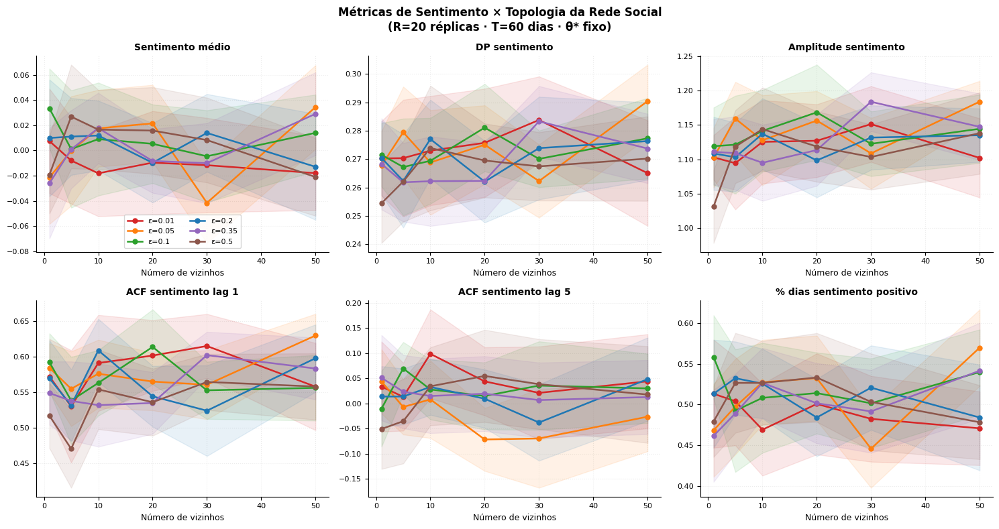

✓ Figura 1 salva: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_sentimento.png


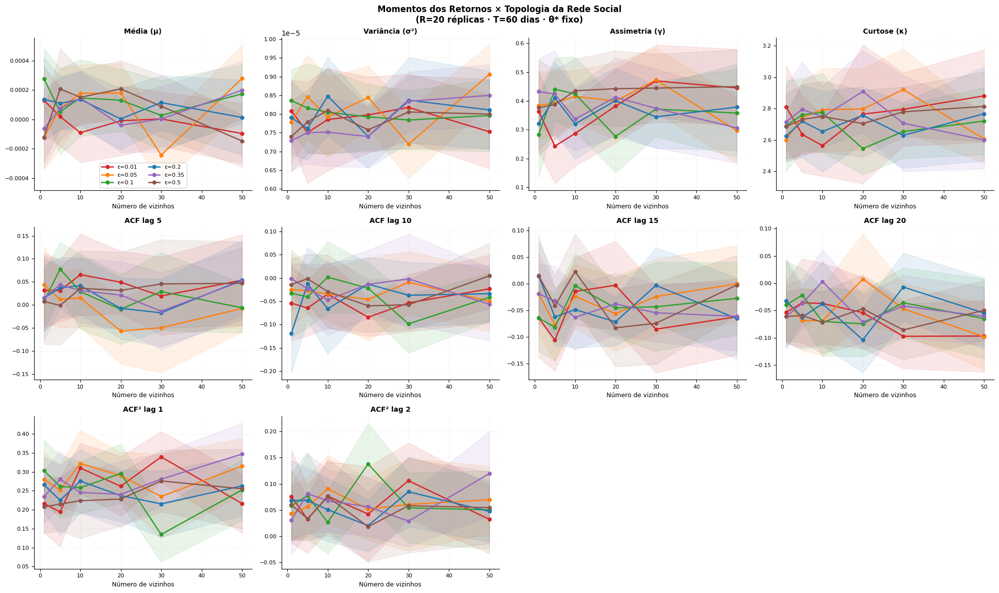

✓ Figura 2 salva: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_momentos.png


NameError: name 'run_model' is not defined

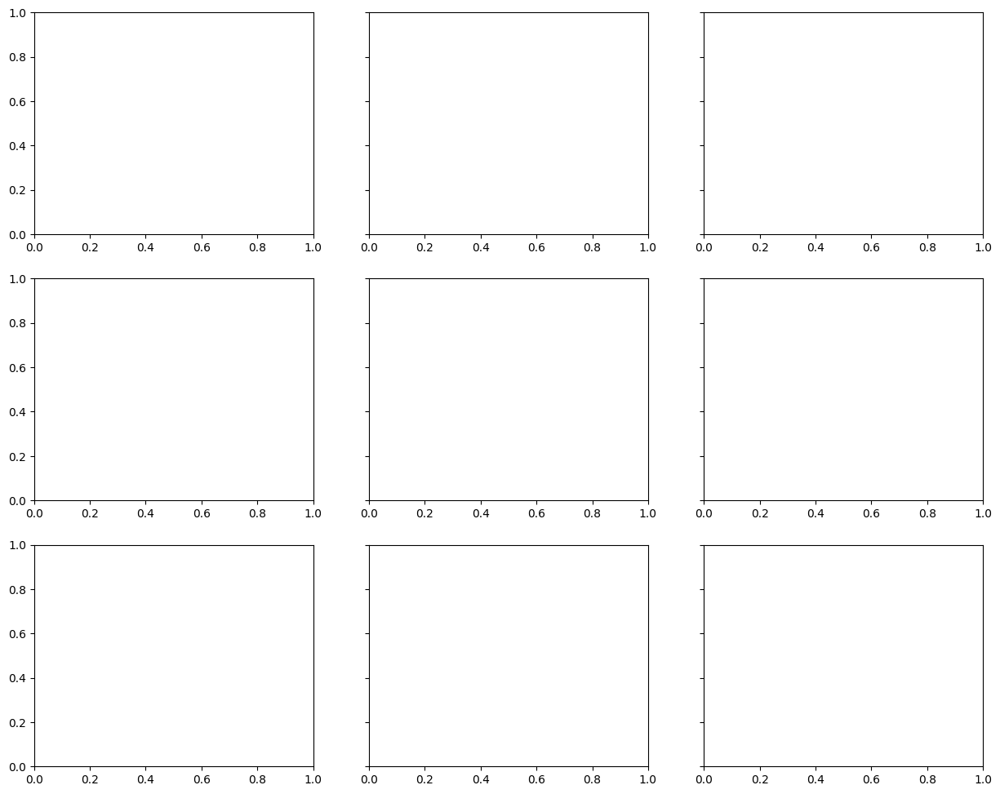

In [ ]:
CORES_EPS = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', '#8c564b']

# ══════════════════════════════════════════════════════════════
# FIGURA 1 — 6 métricas de sentimento
# ══════════════════════════════════════════════════════════════

SENT_LABELS = {
    'sent_media':        'Sentimento médio',
    'sent_std':          'DP sentimento',
    'sent_amplitude':    'Amplitude sentimento',
    'sent_acf1':         'ACF sentimento lag 1',
    'sent_acf5':         'ACF sentimento lag 5',
    'sent_positivo_pct': '% dias sentimento positivo',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flatten()

for j, oname in enumerate(SENT_LABELS):
    ax   = axes_flat[j]
    df_o = df_res[df_res['output'] == oname].copy()

    for eps, cor in zip(GRADE_EPSILON, CORES_EPS):
        df_e = df_o[df_o['epsilon_lf'].round(4) == round(eps, 4)].sort_values('num_vizinhos')
        if df_e.empty:
            continue
        x   = df_e['num_vizinhos'].values
        y   = df_e['mean'].values
        clo = df_e['ci_lo'].values
        chi = df_e['ci_hi'].values

        ax.plot(x, y, color=cor, lw=1.8, marker='o', ms=5,
                label=f'ε={eps}', zorder=3)
        ax.fill_between(x, clo, chi, color=cor, alpha=0.10, zorder=2)

    ax.set_title(SENT_LABELS[oname], fontsize=10, fontweight='bold')
    ax.set_xlabel('Número de vizinhos', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.25, ls=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if j == 0:
        ax.legend(fontsize=8, ncol=2)

fig.suptitle(
    'Métricas de Sentimento × Topologia da Rede Social\n'
    f'(R={N_REP} réplicas · T={HORIZON} dias · θ* fixo)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_sentimento.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura 1 salva: {path}')

# ══════════════════════════════════════════════════════════════
# FIGURA 2 — 10 momentos dos retornos
# ══════════════════════════════════════════════════════════════

MOMENTO_LABELS = {
    'media':      'Média (μ)',
    'variancia':  'Variância (σ²)',
    'assimetria': 'Assimetria (γ)',
    'curtose':    'Curtose (κ)',
    'acf_lag5':   'ACF lag 5',
    'acf_lag10':  'ACF lag 10',
    'acf_lag15':  'ACF lag 15',
    'acf_lag20':  'ACF lag 20',
    'acf2_lag1':  'ACF² lag 1',
    'acf2_lag2':  'ACF² lag 2',
}

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes_flat = axes.flatten()

for j, oname in enumerate(MOMENTO_LABELS):
    ax   = axes_flat[j]
    df_o = df_res[df_res['output'] == oname].copy()

    for eps, cor in zip(GRADE_EPSILON, CORES_EPS):
        df_e = df_o[df_o['epsilon_lf'].round(4) == round(eps, 4)].sort_values('num_vizinhos')
        if df_e.empty:
            continue
        x   = df_e['num_vizinhos'].values
        y   = df_e['mean'].values
        clo = df_e['ci_lo'].values
        chi = df_e['ci_hi'].values

        ax.plot(x, y, color=cor, lw=1.8, marker='o', ms=5,
                label=f'ε={eps}', zorder=3)
        ax.fill_between(x, clo, chi, color=cor, alpha=0.10, zorder=2)

    ax.set_title(MOMENTO_LABELS[oname], fontsize=10, fontweight='bold')
    ax.set_xlabel('Número de vizinhos', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.25, ls=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if j == 0:
        ax.legend(fontsize=8, ncol=2)

# Esconder painel extra
for j in range(len(MOMENTO_LABELS), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Momentos dos Retornos × Topologia da Rede Social\n'
    f'(R={N_REP} réplicas · T={HORIZON} dias · θ* fixo)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_momentos.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura 2 salva: {path}')

# ══════════════════════════════════════════════════════════════
# FIGURA 3 — Trajetória do sentimento
# epsilon_lf ∈ {0.01, 0.1, 0.5} × num_vizinhos ∈ {1, 10, 50}
# ══════════════════════════════════════════════════════════════

CASOS_VIZ = [1, 10, 50]
CASOS_EPS = [0.01, 0.1, 0.5]
CORES_TRAJ = ['#d62728', '#1f77b4', '#2ca02c']

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=True)

for i, eps in enumerate(CASOS_EPS):
    for j, n_viz in enumerate(CASOS_VIZ):
        ax = axes[i, j]

        # 5 réplicas para trajetória
        for r in range(5):
            seed = abs(hash(f'traj_{n_viz}_{eps:.4f}_{r}')) % (2**31)
            _, sent = run_model(num_vizinhos=n_viz, epsilon_lf=eps, seed=seed)
            if len(sent) == HORIZON:
                ax.plot(range(len(sent)), sent,
                        color=CORES_TRAJ[j], lw=1.0, alpha=0.4)

        ax.axhline(0, color='black', lw=0.8, ls=':', alpha=0.5)
        ax.set_ylim(-1.1, 1.1)
        ax.set_title(f'k={n_viz}, ε={eps}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Dia', fontsize=8)
        ax.set_ylabel('Sentimento' if j == 0 else '', fontsize=8)
        ax.grid(True, alpha=0.2, ls=':')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

fig.suptitle(
    'Trajetória do Sentimento Médio × Topologia da Rede\n'
    r'(5 réplicas por combinação · $\theta^*$ fixo)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_trajetoria.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura 3 salva: {path}')

print()
print('══════════════════════════════════════════')
print('  ✓ PLOTS CONCLUÍDOS')
print(f'  Figuras em: {FIG_DIR}')
print('══════════════════════════════════════════')

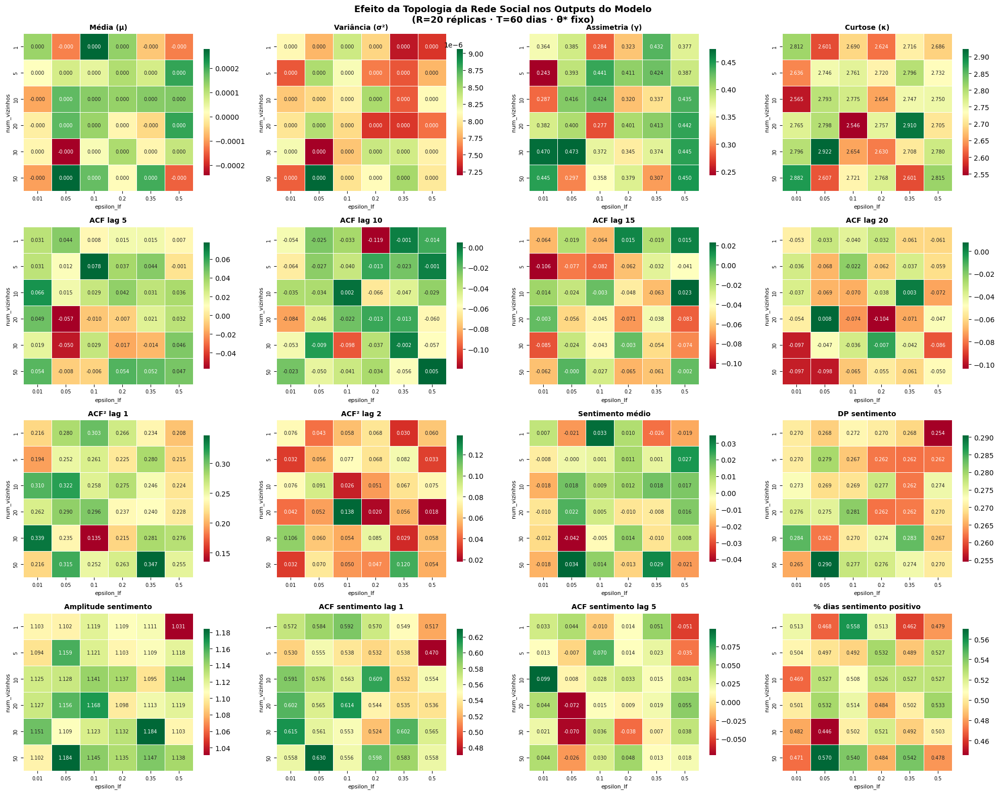

✓ Heatmap salvo: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_heatmap.png


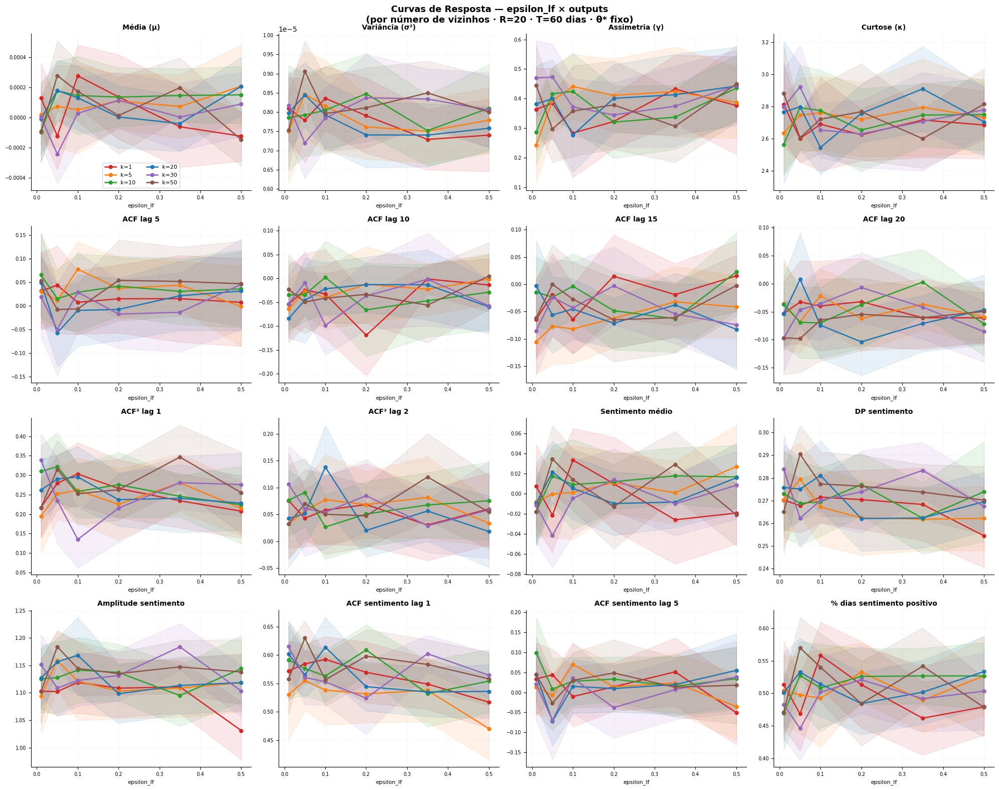

✓ Facet grid salvo: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_facet_epsilon.png


In [ ]:
import seaborn as sns

# ══════════════════════════════════════════════════════════════
# FIGURA 1 — Heatmaps (16 outputs)
# ══════════════════════════════════════════════════════════════

n_cols = 4
n_rows = (len(OUTPUT_LABELS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16))
axes_flat = axes.flatten()

for j, oname in enumerate(OUTPUT_LABELS):
    ax   = axes_flat[j]
    df_o = df_res[df_res['output'] == oname].copy()

    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean'
    )

    sns.heatmap(
        pivot,
        ax=ax,
        cmap='RdYlGn',
        annot=True,
        fmt='.3f',
        linewidths=0.5,
        cbar_kws={'shrink': 0.8},
        annot_kws={'size': 7},
    )
    ax.set_title(OUTPUT_LABELS[oname], fontsize=10, fontweight='bold')
    ax.set_xlabel('epsilon_lf', fontsize=8)
    ax.set_ylabel('num_vizinhos', fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(len(OUTPUT_LABELS), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Efeito da Topologia da Rede Social nos Outputs do Modelo\n'
    f'(R={N_REP} réplicas · T={HORIZON} dias · θ* fixo)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_heatmap.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Heatmap salvo: {path}')

# ══════════════════════════════════════════════════════════════
# FIGURA 2 — Facet grid invertido
# Uma figura por output, eixo X = epsilon_lf, linha por num_vizinhos
# ══════════════════════════════════════════════════════════════

CORES_VIZ = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', '#8c564b']

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16), sharey=False)
axes_flat = axes.flatten()

for j, oname in enumerate(OUTPUT_LABELS):
    ax   = axes_flat[j]
    df_o = df_res[df_res['output'] == oname].copy()

    for n_viz, cor in zip(GRADE_VIZINHOS, CORES_VIZ):
        df_v = df_o[df_o['num_vizinhos'] == n_viz].sort_values('epsilon_lf')
        if df_v.empty:
            continue
        x   = df_v['epsilon_lf'].values
        y   = df_v['mean'].values
        clo = df_v['ci_lo'].values
        chi = df_v['ci_hi'].values

        ax.plot(x, y, color=cor, lw=1.8, marker='o', ms=5,
                label=f'k={n_viz}', zorder=3)
        ax.fill_between(x, clo, chi, color=cor, alpha=0.10, zorder=2)

    ax.set_title(OUTPUT_LABELS[oname], fontsize=10, fontweight='bold')
    ax.set_xlabel('epsilon_lf', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25, ls=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if j == 0:
        ax.legend(fontsize=8, ncol=2)

for j in range(len(OUTPUT_LABELS), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Curvas de Resposta — epsilon_lf × outputs\n'
    f'(por número de vizinhos · R={N_REP} · T={HORIZON} dias · θ* fixo)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_facet_epsilon.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Facet grid salvo: {path}')


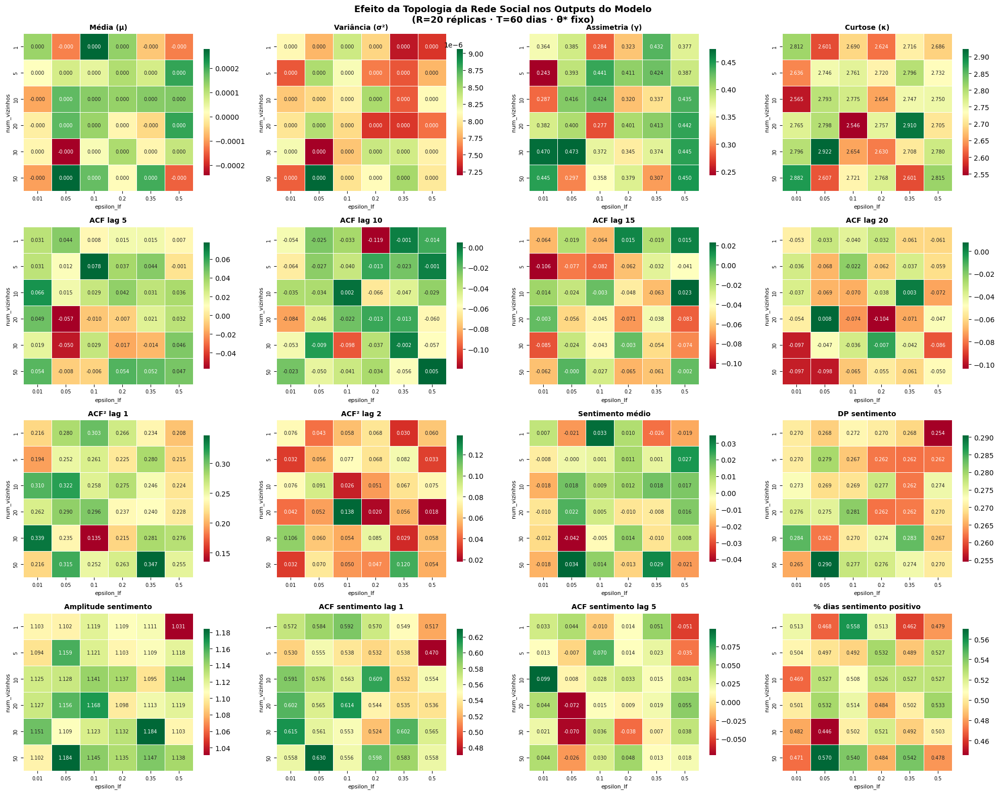

✓ Heatmap salvo: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_heatmap.png


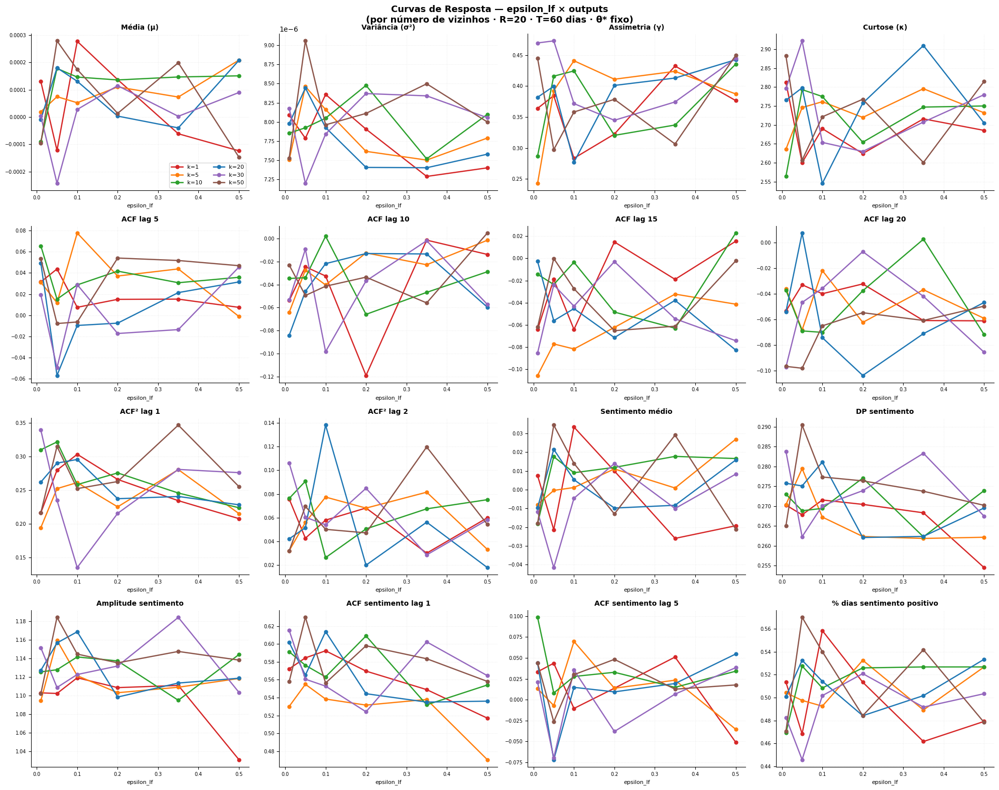

✓ Facet grid salvo: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_facet_epsilon.png


In [ ]:
import seaborn as sns

# ══════════════════════════════════════════════════════════════
# FIGURA 1 — Heatmaps (16 outputs)
# ══════════════════════════════════════════════════════════════

n_cols = 4
n_rows = (len(OUTPUT_LABELS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16))
axes_flat = axes.flatten()

for j, oname in enumerate(OUTPUT_LABELS):
    ax   = axes_flat[j]
    df_o = df_res[df_res['output'] == oname].copy()

    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean'
    )

    sns.heatmap(
        pivot,
        ax=ax,
        cmap='RdYlGn',
        annot=True,
        fmt='.3f',
        linewidths=0.5,
        cbar_kws={'shrink': 0.8},
        annot_kws={'size': 7},
    )
    ax.set_title(OUTPUT_LABELS[oname], fontsize=10, fontweight='bold')
    ax.set_xlabel('epsilon_lf', fontsize=8)
    ax.set_ylabel('num_vizinhos', fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(len(OUTPUT_LABELS), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Efeito da Topologia da Rede Social nos Outputs do Modelo\n'
    f'(R={N_REP} réplicas · T={HORIZON} dias · θ* fixo)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_heatmap.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Heatmap salvo: {path}')

# ══════════════════════════════════════════════════════════════
# FIGURA 2 — Facet grid invertido
# Uma figura por output, eixo X = epsilon_lf, linha por num_vizinhos
# ══════════════════════════════════════════════════════════════

CORES_VIZ = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', '#8c564b']

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16), sharey=False)
axes_flat = axes.flatten()

for j, oname in enumerate(OUTPUT_LABELS):
    ax   = axes_flat[j]
    df_o = df_res[df_res['output'] == oname].copy()

    for n_viz, cor in zip(GRADE_VIZINHOS, CORES_VIZ):
        df_v = df_o[df_o['num_vizinhos'] == n_viz].sort_values('epsilon_lf')
        if df_v.empty:
            continue
        x   = df_v['epsilon_lf'].values
        y   = df_v['mean'].values
        clo = df_v['ci_lo'].values
        chi = df_v['ci_hi'].values

        ax.plot(x, y, color=cor, lw=1.8, marker='o', ms=5,
                label=f'k={n_viz}', zorder=3)
        #ax.fill_between(x, clo, chi, color=cor, alpha=0.10, zorder=2)

    ax.set_title(OUTPUT_LABELS[oname], fontsize=10, fontweight='bold')
    ax.set_xlabel('epsilon_lf', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25, ls=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if j == 0:
        ax.legend(fontsize=8, ncol=2)

for j in range(len(OUTPUT_LABELS), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Curvas de Resposta — epsilon_lf × outputs\n'
    f'(por número de vizinhos · R={N_REP} · T={HORIZON} dias · θ* fixo)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_facet_epsilon.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Facet grid salvo: {path}')

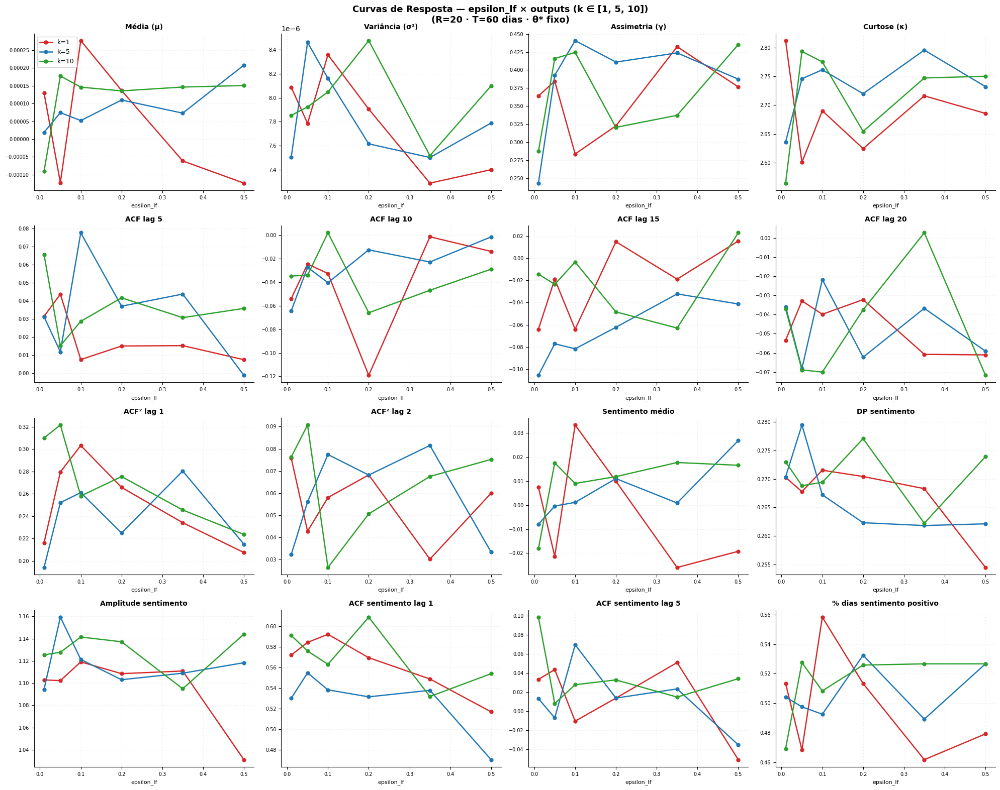

✓ Figura baixo salva: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_facet_epsilon_baixo.png


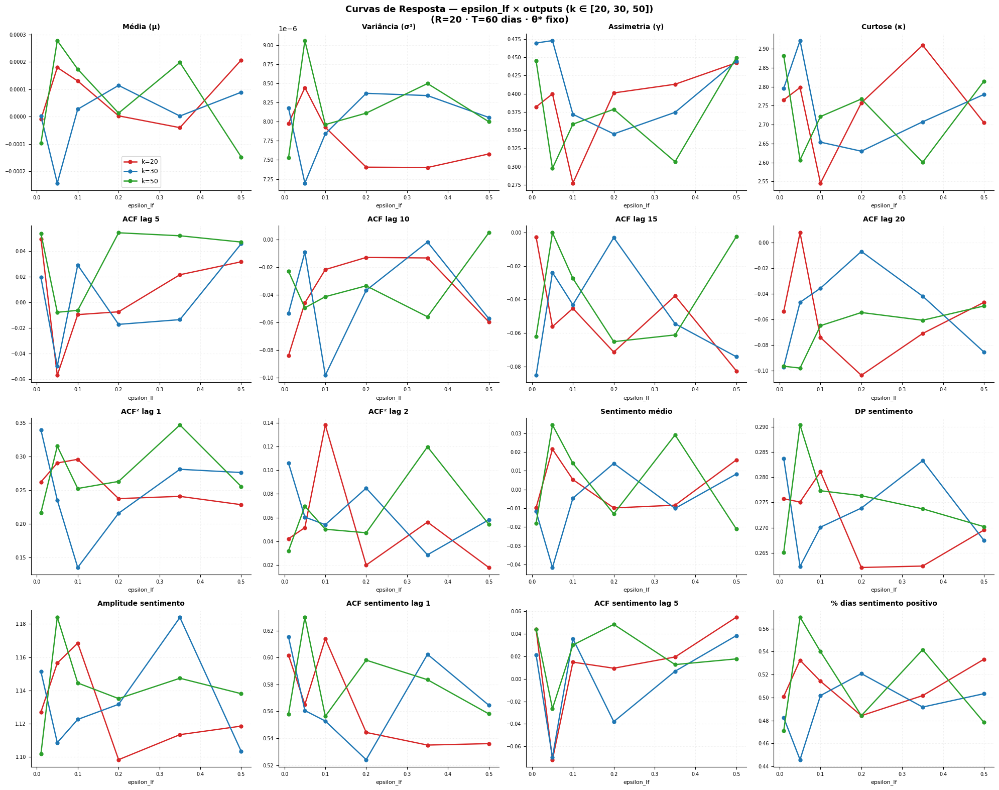

✓ Figura alto salva: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_facet_epsilon_alto.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# FIGURA A — 3 primeiros: k = 1, 5, 10
# ══════════════════════════════════════════════════════════════

CORES_VIZ = ['#d62728', '#1f77b4', '#2ca02c']

for grupo, vizinhos in [("baixo", GRADE_VIZINHOS[:3]), ("alto", GRADE_VIZINHOS[3:])]:

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16), sharey=False)
    axes_flat = axes.flatten()

    for j, oname in enumerate(OUTPUT_LABELS):
        ax   = axes_flat[j]
        df_o = df_res[df_res['output'] == oname].copy()

        for n_viz, cor in zip(vizinhos, CORES_VIZ):
            df_v = df_o[df_o['num_vizinhos'] == n_viz].sort_values('epsilon_lf')
            if df_v.empty:
                continue
            x = df_v['epsilon_lf'].values
            y = df_v['mean'].values

            ax.plot(x, y, color=cor, lw=1.8, marker='o', ms=5,
                    label=f'k={n_viz}', zorder=3)

        ax.set_title(OUTPUT_LABELS[oname], fontsize=10, fontweight='bold')
        ax.set_xlabel('epsilon_lf', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.25, ls=':')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if j == 0:
            ax.legend(fontsize=9, ncol=1)

    for j in range(len(OUTPUT_LABELS), len(axes_flat)):
        axes_flat[j].set_visible(False)

    label = f'k ∈ {vizinhos}'
    fig.suptitle(
        f'Curvas de Resposta — epsilon_lf × outputs ({label})\n'
        f'(R={N_REP} · T={HORIZON} dias · θ* fixo)',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    path = f'{FIG_DIR}/rede_facet_epsilon_{grupo}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'✓ Figura {grupo} salva: {path}')

══════════════════════════════════════════════════════════════════════════════════════════
Output                          Δ_viz(%)   ρ_viz mono_viz         Δ_eps(%)   ρ_eps mono_eps
──────────────────────────────────────────────────────────────────────────────────────────
Sentimento médio                   921.6  -0.143 não-monótona       1067.0   0.429 não-monótona
ACF sentimento lag 5               236.0  -0.143 não-monótona        400.7  -0.371 não-monótona
Média (μ)                          173.1  -0.257 não-monótona        219.8   0.314 não-monótona
ACF lag 5                          158.6  -0.314 não-monótona        228.1   0.086 não-monótona
ACF lag 15                         110.8  -0.086 não-monótona         70.4   0.486 não-monótona
ACF lag 20                          45.0  -0.886 decrescente          32.8   0.429 não-monótona
ACF lag 10                          40.3  -0.029 não-monótona         78.0   0.714 não-monótona
ACF² lag 2                          18.3   0.429 não-m

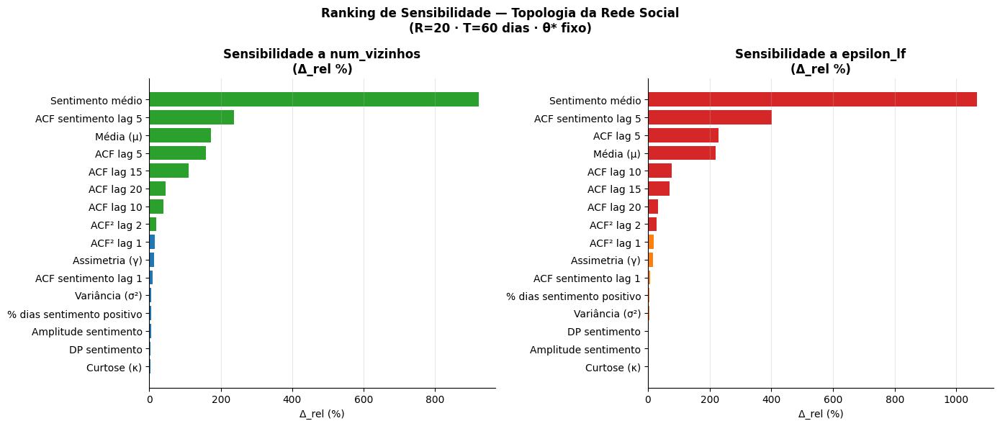

✓ Ranking salvo: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_ranking_sensibilidade.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# Δ_rel — Sensibilidade dos outputs à topologia da rede
# ══════════════════════════════════════════════════════════════

from scipy.stats import spearmanr

rows = []

for oname in OUTPUT_LABELS:
    df_o = df_res[df_res['output'] == oname].copy()

    # ── Sensibilidade a num_vizinhos (média sobre epsilon_lf) ──
    df_viz = df_o.groupby('num_vizinhos')['mean'].mean().reset_index()
    y_viz  = df_viz['mean'].values
    x_viz  = df_viz['num_vizinhos'].values

    delta_viz = (y_viz.max() - y_viz.min()) / (abs(y_viz.mean()) + 1e-12) * 100
    rho_viz, p_viz = spearmanr(x_viz, y_viz)

    # ── Sensibilidade a epsilon_lf (média sobre num_vizinhos) ──
    df_eps = df_o.groupby('epsilon_lf')['mean'].mean().reset_index()
    y_eps  = df_eps['mean'].values
    x_eps  = df_eps['epsilon_lf'].values

    delta_eps = (y_eps.max() - y_eps.min()) / (abs(y_eps.mean()) + 1e-12) * 100
    rho_eps, p_eps = spearmanr(x_eps, y_eps)

    rows.append({
        'output':       OUTPUT_LABELS[oname],
        'Δ_viz (%)':    round(delta_viz, 1),
        'ρ_viz':        round(rho_viz, 3),
        'p_viz':        round(p_viz, 3),
        'mono_viz':     'crescente' if (p_viz < 0.05 and rho_viz > 0.6)
                        else 'decrescente' if (p_viz < 0.05 and rho_viz < -0.6)
                        else 'não-monótona',
        'Δ_eps (%)':    round(delta_eps, 1),
        'ρ_eps':        round(rho_eps, 3),
        'p_eps':        round(p_eps, 3),
        'mono_eps':     'crescente' if (p_eps < 0.05 and rho_eps > 0.6)
                        else 'decrescente' if (p_eps < 0.05 and rho_eps < -0.6)
                        else 'não-monótona',
    })

df_delta = pd.DataFrame(rows).sort_values('Δ_viz (%)', ascending=False)

print("═" * 90)
print(f"{'Output':<30} {'Δ_viz(%)':>9} {'ρ_viz':>7} {'mono_viz':<15} {'Δ_eps(%)':>9} {'ρ_eps':>7} {'mono_eps'}")
print("─" * 90)
for _, r in df_delta.iterrows():
    print(f"{r['output']:<30} {r['Δ_viz (%)']:>9.1f} {r['ρ_viz']:>7.3f} {r['mono_viz']:<15} "
          f"{r['Δ_eps (%)']:>9.1f} {r['ρ_eps']:>7.3f} {r['mono_eps']}")
print("═" * 90)

# Salvar
df_delta.to_csv(f'{OUT_DIR}/rede_delta_rel.csv', index=False)
print(f'\n✓ Salvo: {OUT_DIR}/rede_delta_rel.csv')

# ── Ranking visual ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Ranking por num_vizinhos
df_plot = df_delta.sort_values('Δ_viz (%)')
bars = ax1.barh(df_plot['output'], df_plot['Δ_viz (%)'],
                color=['#2ca02c' if x > df_plot['Δ_viz (%)'].median()
                       else '#1f77b4' for x in df_plot['Δ_viz (%)']])
ax1.set_title('Sensibilidade a num_vizinhos\n(Δ_rel %)', fontweight='bold')
ax1.set_xlabel('Δ_rel (%)')
ax1.grid(True, alpha=0.3, axis='x')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Ranking por epsilon_lf
df_plot2 = df_delta.sort_values('Δ_eps (%)')
ax2.barh(df_plot2['output'], df_plot2['Δ_eps (%)'],
         color=['#d62728' if x > df_plot2['Δ_eps (%)'].median()
                else '#ff7f0e' for x in df_plot2['Δ_eps (%)']])
ax2.set_title('Sensibilidade a epsilon_lf\n(Δ_rel %)', fontweight='bold')
ax2.set_xlabel('Δ_rel (%)')
ax2.grid(True, alpha=0.3, axis='x')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle(
    'Ranking de Sensibilidade — Topologia da Rede Social\n'
    f'(R={N_REP} · T={HORIZON} dias · θ* fixo)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_ranking_sensibilidade.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Ranking salvo: {path}')

════════════════════════════════════════════════════════════════════════════════════════════════════
Output                           baseline   Δ*_viz   ρ_viz mono_viz          Δ*_eps   ρ_eps mono_eps
────────────────────────────────────────────────────────────────────────────────────────────────────
Amplitude sentimento             1.131678    0.345   1.000 crescente          0.253  -0.371 não-monótona
ACF sentimento lag 1             0.524088    0.290   0.771 não-monótona       0.265  -0.943 decrescente
ACF lag 15                      -0.002948    0.241  -0.086 não-monótona       0.138   0.486 não-monótona
Média (μ)                        0.000114    0.215  -0.257 não-monótona       0.250   0.314 não-monótona
ACF lag 5                       -0.017199    0.205  -0.314 não-monótona       0.219   0.086 não-monótona
Sentimento médio                 0.013943    0.195  -0.143 não-monótona       0.209   0.429 não-monótona
DP sentimento                    0.273886    0.185   1.000 crescente

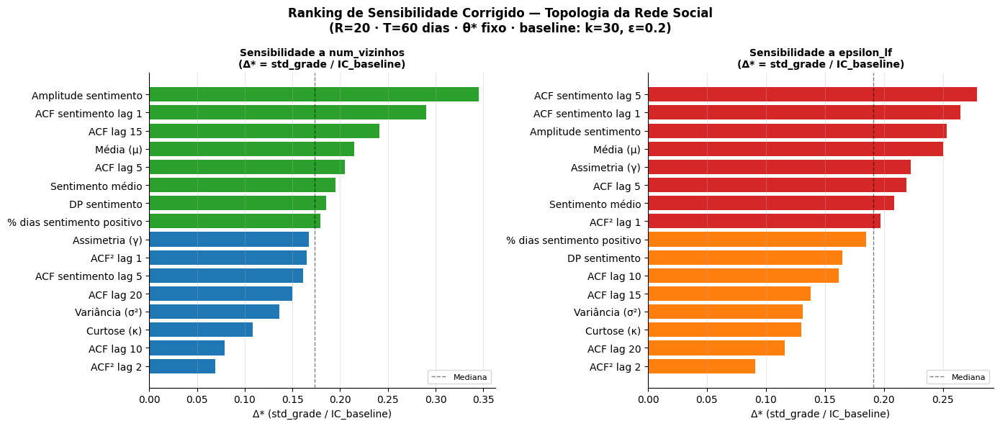

✓ Ranking corrigido salvo: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_ranking_corrigido.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# Δ_rel corrigido — std entre pontos da grade / std baseline
# ══════════════════════════════════════════════════════════════

# Calcular baseline (θ* fixo, média sobre todas as combinações
# onde num_vizinhos=30 e epsilon_lf=0.2 — valores calibrados)
N_VIZ_BASE = 30
EPS_BASE   = 0.2

rows = []

for oname in OUTPUT_LABELS:
    df_o = df_res[df_res['output'] == oname].copy()

    # Baseline — combinação calibrada
    df_base = df_o[
        (df_o['num_vizinhos'] == N_VIZ_BASE) &
        (df_o['epsilon_lf'].round(2) == EPS_BASE)
    ]
    baseline_mean = df_base['mean'].values[0] if len(df_base) > 0 else np.nan
    baseline_ci   = (df_base['ci_hi'].values[0] - df_base['ci_lo'].values[0]) / 2 \
                    if len(df_base) > 0 else np.nan

    # ── Sensibilidade a num_vizinhos ──────────────────────────
    df_viz = df_o.groupby('num_vizinhos')['mean'].mean().reset_index()
    y_viz  = df_viz['mean'].values
    x_viz  = df_viz['num_vizinhos'].values

    std_viz   = y_viz.std(ddof=1)
    delta_viz = std_viz / (abs(baseline_ci) + 1e-12) if not np.isnan(baseline_ci) else np.nan
    rho_viz, p_viz = spearmanr(x_viz, y_viz)

    # ── Sensibilidade a epsilon_lf ────────────────────────────
    df_eps = df_o.groupby('epsilon_lf')['mean'].mean().reset_index()
    y_eps  = df_eps['mean'].values
    x_eps  = df_eps['epsilon_lf'].values

    std_eps   = y_eps.std(ddof=1)
    delta_eps = std_eps / (abs(baseline_ci) + 1e-12) if not np.isnan(baseline_ci) else np.nan
    rho_eps, p_eps = spearmanr(x_eps, y_eps)

    rows.append({
        'output':       OUTPUT_LABELS[oname],
        'baseline':     round(baseline_mean, 6) if not np.isnan(baseline_mean) else np.nan,
        'Δ*_viz':       round(delta_viz, 3),
        'ρ_viz':        round(rho_viz, 3),
        'p_viz':        round(p_viz, 3),
        'mono_viz':     'crescente'   if (p_viz < 0.05 and rho_viz >  0.6) else
                        'decrescente' if (p_viz < 0.05 and rho_viz < -0.6) else
                        'não-monótona',
        'Δ*_eps':       round(delta_eps, 3),
        'ρ_eps':        round(rho_eps, 3),
        'p_eps':        round(p_eps, 3),
        'mono_eps':     'crescente'   if (p_eps < 0.05 and rho_eps >  0.6) else
                        'decrescente' if (p_eps < 0.05 and rho_eps < -0.6) else
                        'não-monótona',
    })

df_delta2 = pd.DataFrame(rows).sort_values('Δ*_viz', ascending=False)

print("═" * 100)
print(f"{'Output':<30} {'baseline':>10} {'Δ*_viz':>8} {'ρ_viz':>7} {'mono_viz':<15} {'Δ*_eps':>8} {'ρ_eps':>7} {'mono_eps'}")
print("─" * 100)
for _, r in df_delta2.iterrows():
    print(f"{r['output']:<30} {r['baseline']:>10.6f} {r['Δ*_viz']:>8.3f} {r['ρ_viz']:>7.3f} "
          f"{r['mono_viz']:<15} {r['Δ*_eps']:>8.3f} {r['ρ_eps']:>7.3f} {r['mono_eps']}")
print("═" * 100)

# Salvar
df_delta2.to_csv(f'{OUT_DIR}/rede_delta_corrigido.csv', index=False)

# ── Ranking visual ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, titulo, cor_alto, cor_baixo in [
    (ax1, 'Δ*_viz', 'Sensibilidade a num_vizinhos\n(Δ* = std_grade / IC_baseline)', '#2ca02c', '#1f77b4'),
    (ax2, 'Δ*_eps', 'Sensibilidade a epsilon_lf\n(Δ* = std_grade / IC_baseline)',   '#d62728', '#ff7f0e'),
]:
    df_plot = df_delta2.sort_values(col)
    mediana = df_plot[col].median()
    cores   = [cor_alto if x > mediana else cor_baixo for x in df_plot[col]]

    ax.barh(df_plot['output'], df_plot[col], color=cores)
    ax.axvline(mediana, color='black', lw=1, ls='--', alpha=0.5, label='Mediana')
    ax.set_title(titulo, fontweight='bold', fontsize=10)
    ax.set_xlabel('Δ* (std_grade / IC_baseline)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    'Ranking de Sensibilidade Corrigido — Topologia da Rede Social\n'
    f'(R={N_REP} · T={HORIZON} dias · θ* fixo · baseline: k={N_VIZ_BASE}, ε={EPS_BASE})',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_ranking_corrigido.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Ranking corrigido salvo: {path}')

═══════════════════════════════════════════════════════════════════════════════════════════════
Output                           CV_viz   ρ_viz mono_viz          CV_eps   ρ_eps mono_eps
───────────────────────────────────────────────────────────────────────────────────────────────
Sentimento médio                 3.3073  -0.143 não-monótona      3.5513   0.429 não-monótona
ACF sentimento lag 5             0.7801  -0.143 não-monótona      1.3497  -0.371 não-monótona
ACF lag 5                        0.6989  -0.314 não-monótona      0.7471   0.086 não-monótona
Média (μ)                        0.6158  -0.257 não-monótona      0.7160   0.314 não-monótona
ACF lag 15                       0.4265  -0.086 não-monótona      0.2447   0.486 não-monótona
ACF lag 20                       0.1748  -0.886 decrescente       0.1343   0.429 não-monótona
ACF lag 10                       0.1518  -0.029 não-monótona      0.3129   0.714 não-monótona
ACF² lag 2                       0.0768   0.429 não-monótona

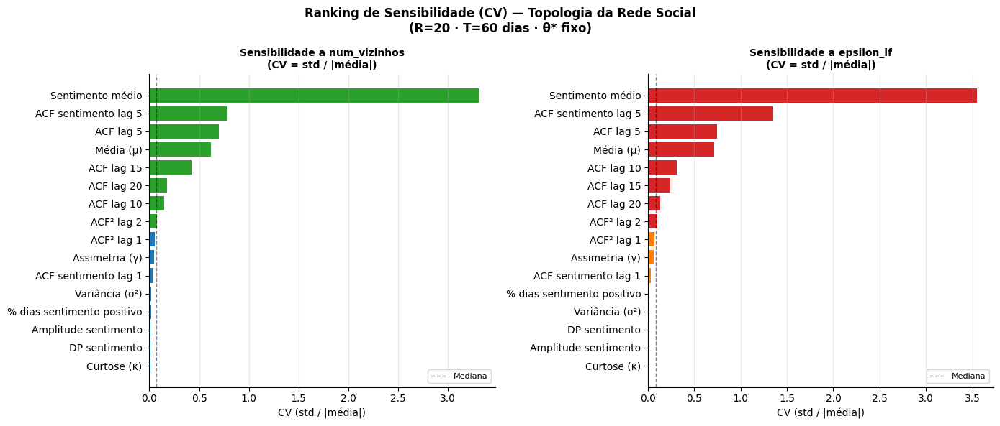

✓ Ranking CV salvo: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_ranking_cv.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# Coeficiente de Variação — std / |média|
# ══════════════════════════════════════════════════════════════

rows = []

for oname in OUTPUT_LABELS:
    df_o = df_res[df_res['output'] == oname].copy()

    # ── Sensibilidade a num_vizinhos ──────────────────────────
    df_viz = df_o.groupby('num_vizinhos')['mean'].mean().reset_index()
    y_viz  = df_viz['mean'].values
    x_viz  = df_viz['num_vizinhos'].values

    cv_viz = y_viz.std(ddof=1) / (abs(y_viz.mean()) + 1e-12)
    rho_viz, p_viz = spearmanr(x_viz, y_viz)

    # ── Sensibilidade a epsilon_lf ────────────────────────────
    df_eps = df_o.groupby('epsilon_lf')['mean'].mean().reset_index()
    y_eps  = df_eps['mean'].values
    x_eps  = df_eps['epsilon_lf'].values

    cv_eps = y_eps.std(ddof=1) / (abs(y_eps.mean()) + 1e-12)
    rho_eps, p_eps = spearmanr(x_eps, y_eps)

    rows.append({
        'output':    OUTPUT_LABELS[oname],
        'CV_viz':    round(cv_viz, 4),
        'ρ_viz':     round(rho_viz, 3),
        'p_viz':     round(p_viz, 3),
        'mono_viz':  'crescente'   if (p_viz < 0.05 and rho_viz >  0.6) else
                     'decrescente' if (p_viz < 0.05 and rho_viz < -0.6) else
                     'não-monótona',
        'CV_eps':    round(cv_eps, 4),
        'ρ_eps':     round(rho_eps, 3),
        'p_eps':     round(p_eps, 3),
        'mono_eps':  'crescente'   if (p_eps < 0.05 and rho_eps >  0.6) else
                     'decrescente' if (p_eps < 0.05 and rho_eps < -0.6) else
                     'não-monótona',
    })

df_cv = pd.DataFrame(rows).sort_values('CV_viz', ascending=False)

print("═" * 95)
print(f"{'Output':<30} {'CV_viz':>8} {'ρ_viz':>7} {'mono_viz':<15} {'CV_eps':>8} {'ρ_eps':>7} {'mono_eps'}")
print("─" * 95)
for _, r in df_cv.iterrows():
    print(f"{r['output']:<30} {r['CV_viz']:>8.4f} {r['ρ_viz']:>7.3f} "
          f"{r['mono_viz']:<15} {r['CV_eps']:>8.4f} {r['ρ_eps']:>7.3f} {r['mono_eps']}")
print("═" * 95)

df_cv.to_csv(f'{OUT_DIR}/rede_cv.csv', index=False)

# ── Ranking visual ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, titulo, cor_alto, cor_baixo in [
    (ax1, 'CV_viz', 'Sensibilidade a num_vizinhos\n(CV = std / |média|)', '#2ca02c', '#1f77b4'),
    (ax2, 'CV_eps', 'Sensibilidade a epsilon_lf\n(CV = std / |média|)',   '#d62728', '#ff7f0e'),
]:
    df_plot = df_cv.sort_values(col)
    mediana = df_plot[col].median()
    cores   = [cor_alto if x > mediana else cor_baixo for x in df_plot[col]]

    ax.barh(df_plot['output'], df_plot[col], color=cores)
    ax.axvline(mediana, color='black', lw=1, ls='--', alpha=0.5, label='Mediana')
    ax.set_title(titulo, fontweight='bold', fontsize=10)
    ax.set_xlabel('CV (std / |média|)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    'Ranking de Sensibilidade (CV) — Topologia da Rede Social\n'
    f'(R={N_REP} · T={HORIZON} dias · θ* fixo)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_ranking_cv.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Ranking CV salvo: {path}')

In [ ]:
# ══════════════════════════════════════════════════════════════
# Tabela resumo — média por (num_vizinhos, epsilon_lf)
# para cada métrica, pivotada para apresentação
# ══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

df_res = pd.read_csv(RESULT_FILE)

# Métricas a incluir na tabela
METRICAS = {
    'sent_media':        'Sentimento médio',
    'sent_std':          'Polarização (DP)',
    'sent_positivo_pct': '% dias positivo',
    'sent_amplitude':    'Amplitude',
    'sent_acf1':         'Persistência (ACF lag 1)',
    'sent_acf5':         'ACF sentimento lag 5',
    'media':             'Média retornos (μ)',
    'variancia':         'Variância retornos (σ²)',
    'acf_lag5':          'ACF retornos lag 5',
    'acf2_lag1':         'ACF² retornos lag 1',
}

tabelas = {}

for oname, label in METRICAS.items():
    df_o = df_res[df_res['output'] == oname].copy()
    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean',
        aggfunc='mean'
    ).round(4)
    pivot.index.name   = 'k (vizinhos)'
    pivot.columns.name = 'ε (epsilon_lf)'
    tabelas[label] = pivot

# Imprimir todas as tabelas
for label, pivot in tabelas.items():
    print(f"\n{'═'*70}")
    print(f"  {label}")
    print(f"{'─'*70}")
    print(pivot.to_string())

print(f"\n{'═'*70}")


══════════════════════════════════════════════════════════════════════
  Sentimento médio
──────────────────────────────────────────────────────────────────────
ε (epsilon_lf)    0.01    0.05    0.10    0.20    0.35    0.50
k (vizinhos)                                                  
1               0.0075 -0.0213  0.0334  0.0099 -0.0260 -0.0192
5              -0.0080 -0.0004  0.0011  0.0111  0.0009  0.0269
10             -0.0181  0.0176  0.0090  0.0119  0.0178  0.0166
20             -0.0097  0.0215  0.0053 -0.0098 -0.0083  0.0158
30             -0.0117 -0.0416 -0.0046  0.0139 -0.0101  0.0083
50             -0.0180  0.0344  0.0140 -0.0130  0.0291 -0.0211

══════════════════════════════════════════════════════════════════════
  Polarização (DP)
──────────────────────────────────────────────────────────────────────
ε (epsilon_lf)    0.01    0.05    0.10    0.20    0.35    0.50
k (vizinhos)                                                  
1               0.2703  0.2678  0.2715  0.2704

In [ ]:
# ══════════════════════════════════════════════════════════════
# Tabela resumo corrigida
# ══════════════════════════════════════════════════════════════

METRICAS = {
    'sent_media':        'Sentimento médio',
    'sent_std':          'Volatilidade do sentimento (DP temporal)',
    'sent_positivo_pct': '% dias sentimento positivo',
    'sent_amplitude':    'Amplitude do sentimento',
    'sent_acf1':         'Persistência do sentimento (ACF lag 1)',
    'sent_acf5':         'ACF sentimento lag 5',
    'media':             'Média dos retornos (μ)',
    'variancia':         'Volatilidade anualizada (σ√252)',
    'acf_lag5':          'ACF retornos lag 5',
    'acf2_lag1':         'ACF² retornos lag 1',
}

tabelas = {}

for oname, label in METRICAS.items():
    df_o = df_res[df_res['output'] == oname].copy()

    # Converter variância → DP anualizado
    if oname == 'variancia':
        df_o['mean'] = np.sqrt(df_o['mean'] * 252)

    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean',
        aggfunc='mean'
    ).round(4)
    pivot.index.name   = 'k (vizinhos)'
    pivot.columns.name = 'ε (epsilon_lf)'
    tabelas[label] = pivot

# Imprimir
for label, pivot in tabelas.items():
    print(f"\n{'═'*70}")
    print(f"  {label}")
    print(f"{'─'*70}")
    print(pivot.to_string())

print(f"\n{'═'*70}")


══════════════════════════════════════════════════════════════════════
  Sentimento médio
──────────────────────────────────────────────────────────────────────
ε (epsilon_lf)    0.01    0.05    0.10    0.20    0.35    0.50
k (vizinhos)                                                  
1               0.0075 -0.0213  0.0334  0.0099 -0.0260 -0.0192
5              -0.0080 -0.0004  0.0011  0.0111  0.0009  0.0269
10             -0.0181  0.0176  0.0090  0.0119  0.0178  0.0166
20             -0.0097  0.0215  0.0053 -0.0098 -0.0083  0.0158
30             -0.0117 -0.0416 -0.0046  0.0139 -0.0101  0.0083
50             -0.0180  0.0344  0.0140 -0.0130  0.0291 -0.0211

══════════════════════════════════════════════════════════════════════
  Volatilidade do sentimento (DP temporal)
──────────────────────────────────────────────────────────────────────
ε (epsilon_lf)    0.01    0.05    0.10    0.20    0.35    0.50
k (vizinhos)                                                  
1               0.2703

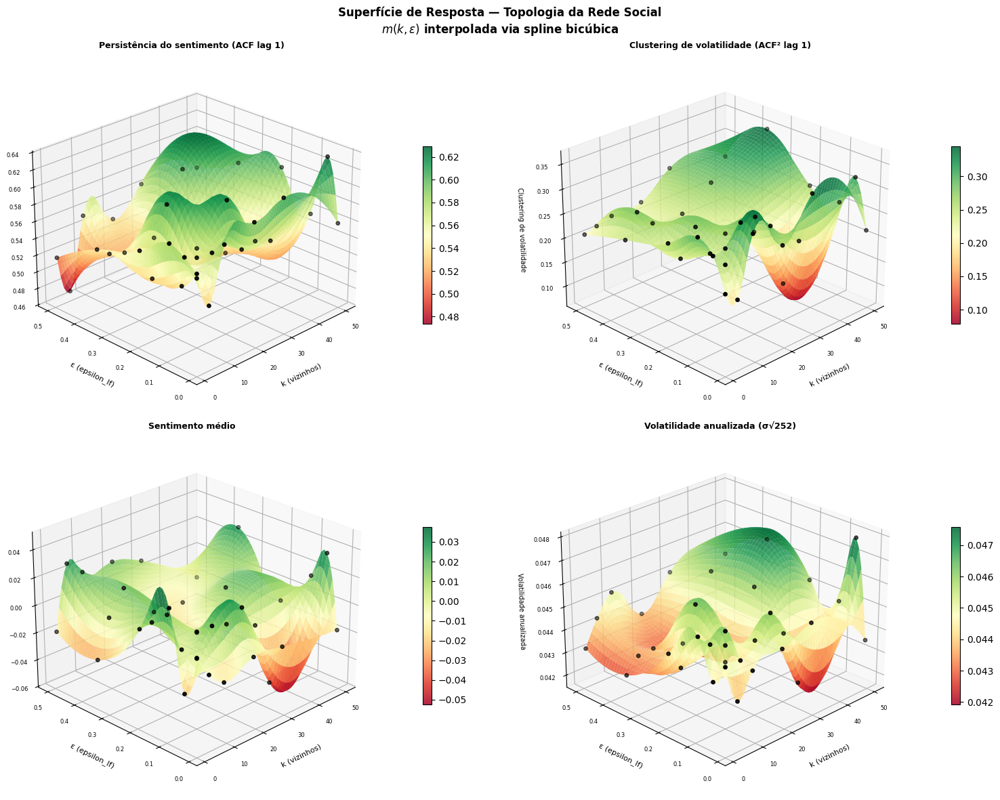

✓ Superfície 3D salva: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_superficie_3d.png


In [ ]:
from scipy.interpolate import RectBivariateSpline
import matplotlib.pyplot as plt
import numpy as np

# ── Outputs para plotar ───────────────────────────────────────
OUTPUTS_3D = {
    'sent_acf1':  'Persistência do sentimento (ACF lag 1)',
    'acf2_lag1':  'Clustering de volatilidade (ACF² lag 1)',
    'sent_media': 'Sentimento médio',
    'variancia':  'Volatilidade anualizada (σ√252)',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                         subplot_kw={'projection': '3d'})
axes_flat = axes.flatten()

for j, (oname, label) in enumerate(OUTPUTS_3D.items()):
    ax   = axes_flat[j]
    df_o = df_res[df_res['output'] == oname].copy()

    # Converter variância → DP anualizado
    if oname == 'variancia':
        df_o['mean'] = np.sqrt(df_o['mean'] * 252)

    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean',
        aggfunc='mean'
    )

    k_vals   = pivot.index.values.astype(float)
    eps_vals = pivot.columns.values.astype(float)
    Z        = pivot.values

    # Interpolação na grade fina
    spline   = RectBivariateSpline(k_vals, eps_vals, Z, kx=2, ky=2)
    k_fine   = np.linspace(k_vals.min(),   k_vals.max(),   50)
    eps_fine = np.linspace(eps_vals.min(), eps_vals.max(), 50)
    K, E     = np.meshgrid(k_fine, eps_fine)
    Z_fine   = spline(k_fine, eps_fine).T  # transposta para alinhar com meshgrid

    # Plot
    surf = ax.plot_surface(K, E, Z_fine, cmap='RdYlGn',
                           alpha=0.85, edgecolor='none')

    # Pontos originais
    K_orig, E_orig = np.meshgrid(k_vals, eps_vals)
    ax.scatter(K_orig.flatten(), E_orig.flatten(), Z.T.flatten(),
               color='black', s=15, zorder=5)

    fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)
    ax.set_xlabel('k (vizinhos)', fontsize=8, labelpad=5)
    ax.set_ylabel('ε (epsilon_lf)', fontsize=8, labelpad=5)
    ax.set_zlabel(label.split('(')[0].strip(), fontsize=7, labelpad=5)
    ax.set_title(label, fontsize=9, fontweight='bold', pad=10)
    ax.tick_params(labelsize=6)
    ax.view_init(elev=25, azim=225)

fig.suptitle(
    'Superfície de Resposta — Topologia da Rede Social\n'
    r'$m(k, \varepsilon)$ interpolada via spline bicúbica',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_superficie_3d.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Superfície 3D salva: {path}')

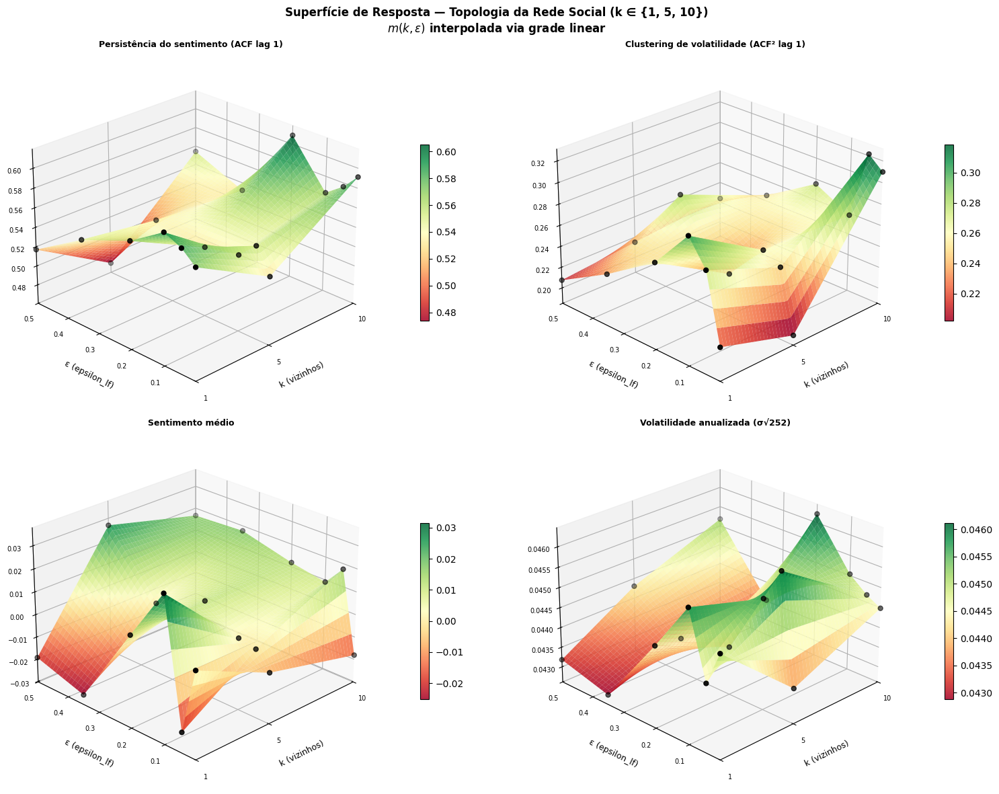

✓ Figura salva: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_superficie_3d_k10.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                         subplot_kw={'projection': '3d'})
axes_flat = axes.flatten()

# Filtrar apenas k ∈ {1, 5, 10}
K_FILTER = [1, 5, 10]

for j, (oname, label) in enumerate(OUTPUTS_3D.items()):
    ax   = axes_flat[j]
    df_o = df_res[df_res['output'] == oname].copy()

    if oname == 'variancia':
        df_o['mean'] = np.sqrt(df_o['mean'] * 252)

    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean',
        aggfunc='mean'
    )

    # Filtrar linhas
    pivot    = pivot.loc[pivot.index.isin(K_FILTER)]
    k_vals   = pivot.index.values.astype(float)
    eps_vals = pivot.columns.values.astype(float)
    Z        = pivot.values

    # Interpolação linear
    interp = RegularGridInterpolator(
        (k_vals, eps_vals), Z, method='linear'
    )

    k_fine   = np.linspace(k_vals.min(),   k_vals.max(),   50)
    eps_fine = np.linspace(eps_vals.min(), eps_vals.max(), 50)
    K, E     = np.meshgrid(k_fine, eps_fine)
    pts      = np.column_stack([K.ravel(), E.ravel()])
    Z_fine   = interp(pts).reshape(K.shape)

    # Superfície
    surf = ax.plot_surface(K, E, Z_fine, cmap='RdYlGn',
                           alpha=0.85, edgecolor='none')

    # Pontos originais
    K_orig, E_orig = np.meshgrid(k_vals, eps_vals)
    ax.scatter(K_orig.flatten(), E_orig.flatten(), Z.T.flatten(),
               color='black', s=25, zorder=5)

    fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)
    ax.set_xlabel('k (vizinhos)', fontsize=9, labelpad=8)
    ax.set_ylabel('ε (epsilon_lf)', fontsize=9, labelpad=8)
    ax.set_xlim(k_vals.min(), k_vals.max())
    ax.set_ylim(eps_vals.min(), eps_vals.max())
    ax.set_xticks(K_FILTER)
    ax.set_title(label, fontsize=9, fontweight='bold', pad=10)
    ax.tick_params(labelsize=7)
    ax.view_init(elev=25, azim=225)

fig.suptitle(
    'Superfície de Resposta — Topologia da Rede Social (k ∈ {1, 5, 10})\n'
    r'$m(k, \varepsilon)$ interpolada via grade linear',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_superficie_3d_k10.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura salva: {path}')

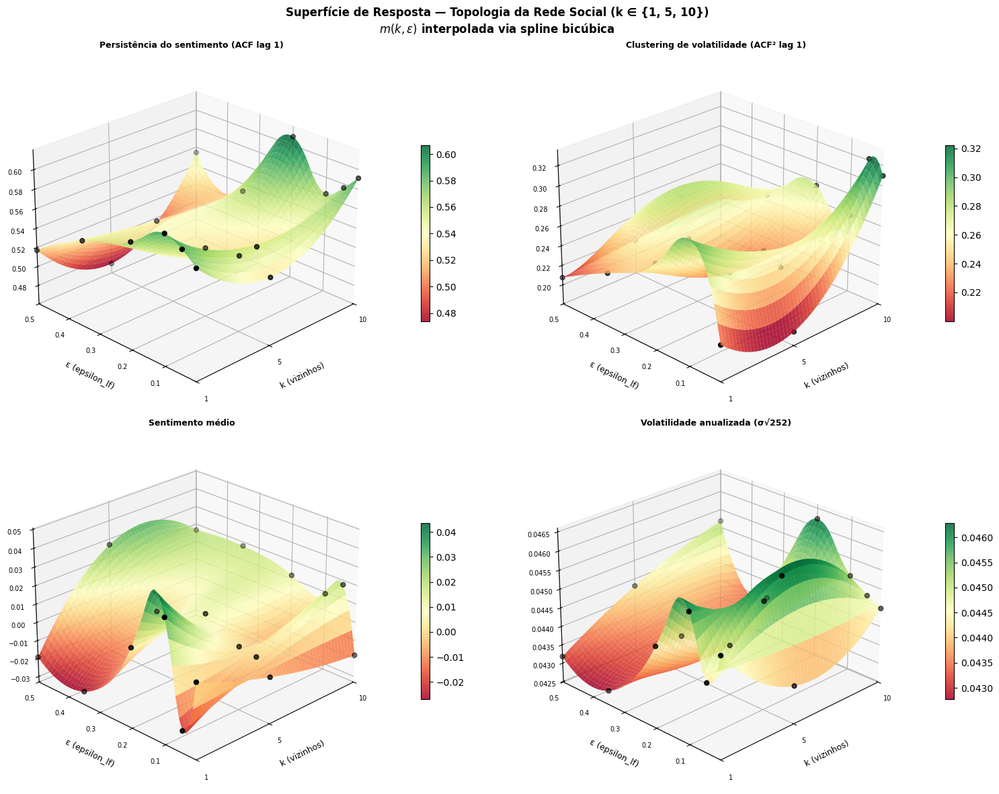

✓ Figura salva: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_superficie_3d_k10_spline.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                         subplot_kw={'projection': '3d'})
axes_flat = axes.flatten()

K_FILTER = [1, 5, 10]

for j, (oname, label) in enumerate(OUTPUTS_3D.items()):
    ax   = axes_flat[j]
    df_o = df_res[df_res['output'] == oname].copy()

    if oname == 'variancia':
        df_o['mean'] = np.sqrt(df_o['mean'] * 252)

    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean',
        aggfunc='mean'
    )

    pivot    = pivot.loc[pivot.index.isin(K_FILTER)]
    k_vals   = pivot.index.values.astype(float)
    eps_vals = pivot.columns.values.astype(float)
    Z        = pivot.values

    # Spline bicúbica — kx=1 pois só temos 3 pontos em k
    spline   = RectBivariateSpline(k_vals, eps_vals, Z, kx=2, ky=2)
    k_fine   = np.linspace(k_vals.min(),   k_vals.max(),   50)
    eps_fine = np.linspace(eps_vals.min(), eps_vals.max(), 50)
    K, E     = np.meshgrid(k_fine, eps_fine)
    Z_fine   = spline(k_fine, eps_fine).T

    surf = ax.plot_surface(K, E, Z_fine, cmap='RdYlGn',
                           alpha=0.85, edgecolor='none')

    K_orig, E_orig = np.meshgrid(k_vals, eps_vals)
    ax.scatter(K_orig.flatten(), E_orig.flatten(), Z.T.flatten(),
               color='black', s=25, zorder=5)

    fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)
    ax.set_xlabel('k (vizinhos)', fontsize=9, labelpad=8)
    ax.set_ylabel('ε (epsilon_lf)', fontsize=9, labelpad=8)
    ax.set_xlim(k_vals.min(), k_vals.max())
    ax.set_ylim(eps_vals.min(), eps_vals.max())
    ax.set_xticks(K_FILTER)
    ax.set_title(label, fontsize=9, fontweight='bold', pad=10)
    ax.tick_params(labelsize=7)
    ax.view_init(elev=25, azim=225)

fig.suptitle(
    'Superfície de Resposta — Topologia da Rede Social (k ∈ {1, 5, 10})\n'
    r'$m(k, \varepsilon)$ interpolada via spline bicúbica',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_superficie_3d_k10_spline.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura salva: {path}')

In [ ]:
from scipy.interpolate import RectBivariateSpline
import matplotlib.pyplot as plt
import numpy as np

K_FILTER = [1, 5, 10]

# Todos os 16 outputs
TODOS_OUTPUTS = {
    'media':             'Média dos retornos (μ)',
    'variancia':         'Volatilidade anualizada (σ√252)',
    'assimetria':        'Assimetria (γ)',
    'curtose':           'Curtose (κ)',
    'acf_lag5':          'ACF retornos lag 5',
    'acf_lag10':         'ACF retornos lag 10',
    'acf_lag15':         'ACF retornos lag 15',
    'acf_lag20':         'ACF retornos lag 20',
    'acf2_lag1':         'ACF² retornos lag 1',
    'acf2_lag2':         'ACF² retornos lag 2',
    'sent_media':        'Sentimento médio',
    'sent_std':          'Volatilidade do sentimento',
    'sent_amplitude':    'Amplitude do sentimento',
    'sent_acf1':         'Persistência do sentimento (ACF lag 1)',
    'sent_acf5':         'ACF sentimento lag 5',
    'sent_positivo_pct': '% dias sentimento positivo',
}

n_cols = 4
n_rows = (len(TODOS_OUTPUTS) + n_cols - 1) // n_cols  # 4 linhas

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 20),
                         subplot_kw={'projection': '3d'})
axes_flat = axes.flatten()

for j, (oname, label) in enumerate(TODOS_OUTPUTS.items()):
    ax   = axes_flat[j]
    df_o = df_res[df_res['output'] == oname].copy()

    if oname == 'variancia':
        df_o['mean'] = np.sqrt(df_o['mean'] * 252)

    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean',
        aggfunc='mean'
    )

    pivot    = pivot.loc[pivot.index.isin(K_FILTER)]
    k_vals   = pivot.index.values.astype(float)
    eps_vals = pivot.columns.values.astype(float)
    Z        = pivot.values

    spline   = RectBivariateSpline(k_vals, eps_vals, Z, kx=2, ky=2)
    k_fine   = np.linspace(k_vals.min(),   k_vals.max(),   50)
    eps_fine = np.linspace(eps_vals.min(), eps_vals.max(), 50)
    K, E     = np.meshgrid(k_fine, eps_fine)
    Z_fine   = spline(k_fine, eps_fine).T

    surf = ax.plot_surface(K, E, Z_fine, cmap='RdYlGn',
                           alpha=0.85, edgecolor='none')

    K_orig, E_orig = np.meshgrid(k_vals, eps_vals)
    ax.scatter(K_orig.flatten(), E_orig.flatten(), Z.T.flatten(),
               color='black', s=20, zorder=5)

    fig.colorbar(surf, ax=ax, shrink=0.4, pad=0.1)
    ax.set_xlabel('k', fontsize=7, labelpad=5)
    ax.set_ylabel('ε', fontsize=7, labelpad=5)
    ax.set_xlim(k_vals.min(), k_vals.max())
    ax.set_ylim(eps_vals.min(), eps_vals.max())
    ax.set_xticks(K_FILTER)
    ax.set_title(label, fontsize=8, fontweight='bold', pad=8)
    ax.tick_params(labelsize=6)
    ax.view_init(elev=25, azim=225)

# Esconder painéis extras
for j in range(len(TODOS_OUTPUTS), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Superfícies de Resposta — 16 Outputs × Topologia da Rede Social (k ∈ {1, 5, 10})\n'
    r'$m(k, \varepsilon)$ interpolada via spline bicúbica',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_superficie_todos_outputs.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura salva: {path}')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from scipy.interpolate import RectBivariateSpline
import matplotlib.pyplot as plt
import numpy as np

K_FILTER = [20, 30, 50]

# Todos os 16 outputs
TODOS_OUTPUTS = {
    'media':             'Média dos retornos (μ)',
    'variancia':         'Volatilidade anualizada (σ√252)',
    'assimetria':        'Assimetria (γ)',
    'curtose':           'Curtose (κ)',
    'acf_lag5':          'ACF retornos lag 5',
    'acf_lag10':         'ACF retornos lag 10',
    'acf_lag15':         'ACF retornos lag 15',
    'acf_lag20':         'ACF retornos lag 20',
    'acf2_lag1':         'ACF² retornos lag 1',
    'acf2_lag2':         'ACF² retornos lag 2',
    'sent_media':        'Sentimento médio',
    'sent_std':          'Volatilidade do sentimento',
    'sent_amplitude':    'Amplitude do sentimento',
    'sent_acf1':         'Persistência do sentimento (ACF lag 1)',
    'sent_acf5':         'ACF sentimento lag 5',
    'sent_positivo_pct': '% dias sentimento positivo',
}

n_cols = 4
n_rows = (len(TODOS_OUTPUTS) + n_cols - 1) // n_cols  # 4 linhas

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 20),
                         subplot_kw={'projection': '3d'})
axes_flat = axes.flatten()

for j, (oname, label) in enumerate(TODOS_OUTPUTS.items()):
    ax   = axes_flat[j]
    df_o = df_res[df_res['output'] == oname].copy()

    if oname == 'variancia':
        df_o['mean'] = np.sqrt(df_o['mean'] * 252)

    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean',
        aggfunc='mean'
    )

    pivot    = pivot.loc[pivot.index.isin(K_FILTER)]
    k_vals   = pivot.index.values.astype(float)
    eps_vals = pivot.columns.values.astype(float)
    Z        = pivot.values

    spline   = RectBivariateSpline(k_vals, eps_vals, Z, kx=2, ky=2)
    k_fine   = np.linspace(k_vals.min(),   k_vals.max(),   50)
    eps_fine = np.linspace(eps_vals.min(), eps_vals.max(), 50)
    K, E     = np.meshgrid(k_fine, eps_fine)
    Z_fine   = spline(k_fine, eps_fine).T

    surf = ax.plot_surface(K, E, Z_fine, cmap='RdYlGn',
                           alpha=0.85, edgecolor='none')

    K_orig, E_orig = np.meshgrid(k_vals, eps_vals)
    ax.scatter(K_orig.flatten(), E_orig.flatten(), Z.T.flatten(),
               color='black', s=20, zorder=5)

    fig.colorbar(surf, ax=ax, shrink=0.4, pad=0.1)
    ax.set_xlabel('k', fontsize=7, labelpad=5)
    ax.set_ylabel('ε', fontsize=7, labelpad=5)
    ax.set_xlim(k_vals.min(), k_vals.max())
    ax.set_ylim(eps_vals.min(), eps_vals.max())
    ax.set_xticks(K_FILTER)
    ax.set_title(label, fontsize=8, fontweight='bold', pad=8)
    ax.tick_params(labelsize=6)
    ax.view_init(elev=25, azim=225)

# Esconder painéis extras
for j in range(len(TODOS_OUTPUTS), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Superfícies de Resposta — 16 Outputs × Topologia da Rede Social (k ∈ {20, 30, 50})\n'
    r'$m(k, \varepsilon)$ interpolada via spline bicúbica',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/rede_superficie_todos_outputs.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura salva: {path}')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ══════════════════════════════════════════════════════════════
# Estimativa analítica de k_ef para cada combinação (k, ε)
# ══════════════════════════════════════════════════════════════

np.random.seed(42)

def estimar_k_ef(k, epsilon, n_rep=10, n_pf=600, n_pj=200):
    """
    Estima o grau efetivo médio para uma combinação (k, ε).
    Repete n_rep vezes para estabilizar a estimativa.
    """
    k_ef_list = []
    for _ in range(n_rep):
        # Gerar população sintética
        lf_pf = np.random.uniform(0.2, 0.7, n_pf)
        lf_pj = np.random.uniform(0.7, 1.0, n_pj)
        lf    = np.concatenate([lf_pf, lf_pj])

        candidatos = []
        for lf_i in lf:
            n_cand = np.sum(np.abs(lf - lf_i) <= epsilon) - 1
            k_ef_i = min(k, n_cand)
            candidatos.append(k_ef_i)

        k_ef_list.append(np.mean(candidatos))

    return float(np.mean(k_ef_list))

# Calcular k_ef para todas as 36 combinações
rows_kef = []
for k in GRADE_VIZINHOS:
    for eps in GRADE_EPSILON:
        k_ef = estimar_k_ef(k, eps)
        rows_kef.append({
            'num_vizinhos': k,
            'epsilon_lf':   round(eps, 4),
            'k_ef':         round(k_ef, 2),
        })

df_kef = pd.DataFrame(rows_kef)

# Pivot para visualização
pivot_kef = df_kef.pivot_table(
    index='num_vizinhos',
    columns='epsilon_lf',
    values='k_ef'
).round(1)

print("k_ef estimado por combinação (k, ε):")
print(pivot_kef.to_string())

# Salvar
df_kef.to_csv(f'{OUT_DIR}/rede_k_ef.csv', index=False)
print(f'\n✓ Salvo: {OUT_DIR}/rede_k_ef.csv')

k_ef estimado por combinação (k, ε):
epsilon_lf    0.01  0.05  0.10  0.20  0.35  0.50
num_vizinhos                                    
1              1.0   1.0   1.0   1.0   1.0   1.0
5              5.0   5.0   5.0   5.0   5.0   5.0
10             9.9  10.0  10.0  10.0  10.0  10.0
20            17.8  20.0  20.0  20.0  20.0  20.0
30            20.9  30.0  30.0  30.0  30.0  30.0
50            21.2  49.8  50.0  50.0  50.0  50.0

✓ Salvo: /content/drive/MyDrive/tese_fii/rede_social/rede_k_ef.csv


═══════════════════════════════════════════════════════════════════════════════════════════════
Output                                 r_P    r_S     R²       coef   p_coef sig
───────────────────────────────────────────────────────────────────────────────────────────────
Amplitude do sentimento              0.480  0.487 0.2302   0.000858   0.0031 ***
Volatilidade do sentimento           0.427  0.354 0.1825   0.000199   0.0094 ***
Volatilidade anualizada (σ√252)      0.341  0.287 0.1161   0.000025   0.0420 **
Persistência do sentimento (ACF lag 1)  0.314  0.249 0.0983   0.000644   0.0626 *
ACF retornos lag 20                 -0.210 -0.252 0.0442  -0.000346   0.2182 
ACF² retornos lag 1                  0.182  0.176 0.0333   0.000491   0.2868 
% dias sentimento positivo           0.129  0.080 0.0165   0.000224   0.4548 
ACF retornos lag 5                  -0.121 -0.052 0.0148  -0.000225   0.4802 
ACF² retornos lag 2                  0.102 -0.013 0.0104   0.000169   0.5541 
ACF sentiment

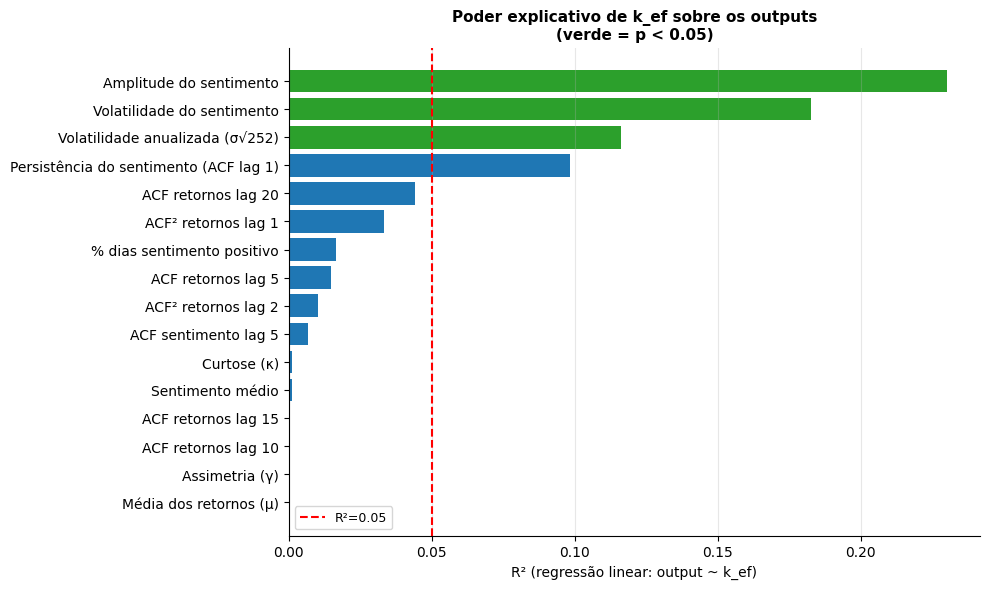

✓ Plot R² salvo: /content/drive/MyDrive/tese_fii/rede_social/figures/rede_r2_k_ef.png


In [ ]:
from scipy.stats import pearsonr, spearmanr
import statsmodels.formula.api as smf

# ── Unir df_res com df_kef ───────────────────────────────────
df_merged = df_res.merge(
    df_kef,
    on=['num_vizinhos', 'epsilon_lf'],
    how='left'
)

# ── Regressão simples: output ~ k_ef ─────────────────────────
rows_reg = []

for oname, label in TODOS_OUTPUTS.items():
    df_o = df_merged[df_merged['output'] == oname].copy()

    if oname == 'variancia':
        df_o['mean'] = np.sqrt(df_o['mean'] * 252)

    y    = df_o['mean'].values
    x    = df_o['k_ef'].values

    # Pearson e Spearman
    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)

    # R² via regressão linear simples
    df_o['y']   = y
    df_o['x']   = x
    modelo      = smf.ols('y ~ x', data=df_o).fit()
    r2          = modelo.rsquared
    coef        = modelo.params['x']
    p_coef      = modelo.pvalues['x']

    rows_reg.append({
        'output':   label,
        'r_pearson': round(r_p, 4),
        'p_pearson': round(p_p, 4),
        'r_spearman': round(r_s, 4),
        'p_spearman': round(p_s, 4),
        'R²':        round(r2, 4),
        'coef':      round(coef, 6),
        'p_coef':    round(p_coef, 4),
        'sig':       '***' if p_coef < 0.01 else
                     '**'  if p_coef < 0.05 else
                     '*'   if p_coef < 0.10 else ''
    })

df_reg = pd.DataFrame(rows_reg).sort_values('R²', ascending=False)

print("═" * 95)
print(f"{'Output':<35} {'r_P':>6} {'r_S':>6} {'R²':>6} {'coef':>10} {'p_coef':>8} {'sig'}")
print("─" * 95)
for _, r in df_reg.iterrows():
    print(f"{r['output']:<35} {r['r_pearson']:>6.3f} {r['r_spearman']:>6.3f} "
          f"{r['R²']:>6.4f} {r['coef']:>10.6f} {r['p_coef']:>8.4f} {r['sig']}")
print("═" * 95)

df_reg.to_csv(f'{OUT_DIR}/rede_regressao_k_ef.csv', index=False)
print(f'\n✓ Salvo: {OUT_DIR}/rede_regressao_k_ef.csv')

# ── Plot: R² por output ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

df_plot = df_reg.sort_values('R²')
cores   = ['#2ca02c' if p < 0.05 else '#1f77b4'
           for p in df_plot['p_coef']]

ax.barh(df_plot['output'], df_plot['R²'], color=cores)
ax.axvline(0.05, color='red', lw=1.5, ls='--', label='R²=0.05')
ax.set_xlabel('R² (regressão linear: output ~ k_ef)', fontsize=10)
ax.set_title('Poder explicativo de k_ef sobre os outputs\n'
             '(verde = p < 0.05)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
path = f'{FIG_DIR}/rede_r2_k_ef.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Plot R² salvo: {path}')

In [ ]:
# ══════════════════════════════════════════════════════════════
# EXPERIMENTO — Epsilon baixo (≤ 0.05)
# ══════════════════════════════════════════════════════════════

import os, copy, time, warnings
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, skew, t as t_dist
from statsmodels.tsa.stattools import acf
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

# ── Configurações ─────────────────────────────────────────────
GRADE_VIZINHOS_2 = [10, 20, 30]
GRADE_EPSILON_2  = [0.01, 0.02, 0.03, 0.04, 0.05]
N_REP_2          = 5
HORIZON_2        = 60
N_JOBS_2         = 2

OUT_DIR_2     = '/content/drive/MyDrive/tese_fii/rede_social_epsilon_baixo'
FIG_DIR_2     = f'{OUT_DIR_2}/figures'
RESULT_FILE_2 = f'{OUT_DIR_2}/resultados.csv'
SERIES_FILE_2 = f'{OUT_DIR_2}/series.csv'
SENT_FILE_2   = f'{OUT_DIR_2}/sentimentos.csv'
os.makedirs(FIG_DIR_2, exist_ok=True)

combinacoes_2 = list(itertools.product(GRADE_VIZINHOS_2, GRADE_EPSILON_2))

print(f'Grade vizinhos : {GRADE_VIZINHOS_2}')
print(f'Grade epsilon  : {GRADE_EPSILON_2}')
print(f'Combinações    : {len(combinacoes_2)}')
print(f'Réplicas/combo : {N_REP_2}')
print(f'Total sim.     : {len(combinacoes_2) * N_REP_2}')
print(f'Tempo est.     : ~{len(combinacoes_2) * N_REP_2 * 20 / N_JOBS_2 / 60:.0f} min')
print(f'Saída          : {OUT_DIR_2}')

# ── Simulador ─────────────────────────────────────────────────
def run_model_2(num_vizinhos, epsilon_lf, seed, T=HORIZON_2):
    np.random.seed(seed)

    params = copy.deepcopy(SIM_PARAMS)
    params["prob_choque_diario"]            = 0.0
    params["choques"]                       = []
    params["agente_pf"]["num_vizinhos"]     = num_vizinhos
    params["agente_pf"]["epsilon_lf"]       = epsilon_lf
    params["agente_pj"]["num_vizinhos"]     = num_vizinhos
    params["agente_pj"]["epsilon_lf"]       = epsilon_lf

    resultado = simular_mercado_e_plotar(
        parametros_sistema=list(THETA_STAR.values()),
        num_dias=T,
        sim_params=params,
        imprimir=False,
    )

    ret        = np.array(resultado[1])[-T:]
    sentimento = np.array(resultado[4], dtype=float)
    ret        = ret[np.isfinite(ret)]
    sentimento = sentimento[np.isfinite(sentimento)]

    return ret, sentimento


def rodar_replica_2(num_vizinhos, epsilon_lf, seed, replica_id):
    ret, sentimento = run_model_2(num_vizinhos, epsilon_lf, seed)
    out = compute_outputs(ret, sentimento)
    return ret, sentimento, out


# ── Varredura ─────────────────────────────────────────────────
if os.path.exists(RESULT_FILE_2):
    df_existing_2 = pd.read_csv(RESULT_FILE_2)
    done_keys_2   = set(zip(
        df_existing_2['num_vizinhos'].astype(int),
        df_existing_2['epsilon_lf'].round(4)
    ))
    print(f'Retomando: {len(done_keys_2)} combinações já concluídas')
else:
    done_keys_2 = set()

pendentes_2 = [
    (nv, ep) for nv, ep in combinacoes_2
    if (int(nv), round(ep, 4)) not in done_keys_2
]
print(f'Pendentes: {len(pendentes_2)}/{len(combinacoes_2)}')

t_exp      = time.time()
all_series = []
all_sents  = []

for idx, (n_viz, eps) in enumerate(pendentes_2):
    t0 = time.time()

    seeds = [
        abs(hash(f'eps2_{n_viz}_{eps:.4f}_{r}')) % (2**31)
        for r in range(N_REP_2)
    ]

    resultados = Parallel(n_jobs=N_JOBS_2)(
        delayed(rodar_replica_2)(n_viz, eps, s, r)
        for r, s in enumerate(seeds)
    )

    recs_momentos = []
    for replica_id, (ret, sentimento, out) in enumerate(resultados):
        recs_momentos.append(out)

        # Série de retornos
        all_series.append(pd.DataFrame({
            'num_vizinhos': n_viz,
            'epsilon_lf':   round(eps, 4),
            'replica':      replica_id,
            'dia':          range(1, len(ret) + 1),
            'log_return':   ret,
        }))

        # Série de sentimento
        all_sents.append(pd.DataFrame({
            'num_vizinhos': n_viz,
            'epsilon_lf':   round(eps, 4),
            'replica':      replica_id,
            'dia':          range(1, len(sentimento) + 1),
            'sentimento':   sentimento,
        }))

    # Agregar e salvar momentos
    agg = aggregate(recs_momentos)
    rows = []
    for oname, st in agg.items():
        rows.append({
            'num_vizinhos': n_viz,
            'epsilon_lf':   round(eps, 4),
            'output':       oname,
            'mean':         st['mean'],
            'ci_lo':        st['ci_lo'],
            'ci_hi':        st['ci_hi'],
        })

    df_ponto = pd.DataFrame(rows)
    if os.path.exists(RESULT_FILE_2):
        df_ponto.to_csv(RESULT_FILE_2, mode='a', header=False, index=False)
    else:
        df_ponto.to_csv(RESULT_FILE_2, index=False)

    t_este  = time.time() - t0
    elapsed = time.time() - t_exp
    restam  = len(pendentes_2) - (idx + 1)
    eta     = restam * t_este / 60

    print(f'[{idx+1:2d}/{len(pendentes_2)}] '
          f'n_viz={n_viz:3d}  eps={eps:.3f}  '
          f'sent={agg["sent_media"]["mean"]:+.4f}  '
          f'acf1={agg["sent_acf1"]["mean"]:+.4f}  '
          f'{t_este:.0f}s  ETA={eta:.1f}min')

# Salvar séries
pd.concat(all_series, ignore_index=True).to_csv(SERIES_FILE_2, index=False)
pd.concat(all_sents,  ignore_index=True).to_csv(SENT_FILE_2,   index=False)

print(f'\n✓ Resultados: {RESULT_FILE_2}')
print(f'✓ Séries:     {SERIES_FILE_2}')
print(f'✓ Sentimentos:{SENT_FILE_2}')
print(f'✓ Concluído em {(time.time()-t_exp)/60:.1f} min')

Grade vizinhos : [10, 20, 30]
Grade epsilon  : [0.01, 0.02, 0.03, 0.04, 0.05]
Combinações    : 15
Réplicas/combo : 5
Total sim.     : 75
Tempo est.     : ~12 min
Saída          : /content/drive/MyDrive/tese_fii/rede_social_epsilon_baixo
Pendentes: 15/15
[ 1/15] n_viz= 10  eps=0.010  sent=-0.0011  acf1=+0.5150  102s  ETA=23.8min
[ 2/15] n_viz= 10  eps=0.020  sent=-0.0431  acf1=+0.5584  83s  ETA=18.0min
[ 3/15] n_viz= 10  eps=0.030  sent=+0.0115  acf1=+0.5478  87s  ETA=17.5min
[ 4/15] n_viz= 10  eps=0.040  sent=+0.0206  acf1=+0.6063  85s  ETA=15.6min
[ 5/15] n_viz= 10  eps=0.050  sent=+0.0193  acf1=+0.5324  87s  ETA=14.4min
[ 6/15] n_viz= 20  eps=0.010  sent=-0.0122  acf1=+0.5679  86s  ETA=12.9min
[ 7/15] n_viz= 20  eps=0.020  sent=+0.0124  acf1=+0.5395  85s  ETA=11.3min
[ 8/15] n_viz= 20  eps=0.030  sent=-0.0422  acf1=+0.6046  87s  ETA=10.2min
[ 9/15] n_viz= 20  eps=0.040  sent=+0.0544  acf1=+0.6373  84s  ETA=8.4min
[10/15] n_viz= 20  eps=0.050  sent=+0.0052  acf1=+0.5152  87s  ETA=7.3m

In [ ]:
# ── Carregar resultados ───────────────────────────────────────
df_res2   = pd.read_csv(RESULT_FILE_2)
df_sent2  = pd.read_csv(SENT_FILE_2)
df_serie2 = pd.read_csv(SERIES_FILE_2)

print(f"Resultados: {df_res2.shape}")
print(f"Sentimentos: {df_sent2.shape}")
print(f"Séries: {df_serie2.shape}")
print(f"Combinações: {df_res2.groupby(['num_vizinhos','epsilon_lf']).ngroups}")

Resultados: (240, 6)
Sentimentos: (4500, 5)
Séries: (4500, 5)
Combinações: 15



═══════════════════════════════════════════════════════
  Sentimento médio
───────────────────────────────────────────────────────
ε     0.01    0.02    0.03    0.04    0.05
k                                         
10 -0.0011 -0.0431  0.0115  0.0206  0.0193
20 -0.0122  0.0124 -0.0422  0.0544  0.0052
30  0.0281  0.0601 -0.0151  0.0394 -0.0012

═══════════════════════════════════════════════════════
  Persistência (ACF lag 1)
───────────────────────────────────────────────────────
ε     0.01    0.02    0.03    0.04    0.05
k                                         
10  0.5150  0.5584  0.5478  0.6063  0.5324
20  0.5679  0.5395  0.6046  0.6373  0.5152
30  0.6191  0.5305  0.5104  0.5457  0.6156

═══════════════════════════════════════════════════════
  % dias positivo
───────────────────────────────────────────────────────
ε     0.01    0.02    0.03    0.04    0.05
k                                         
10  0.4733  0.4433  0.4933  0.5100  0.5433
20  0.5233  0.5200  0.4800  0.5933  0.

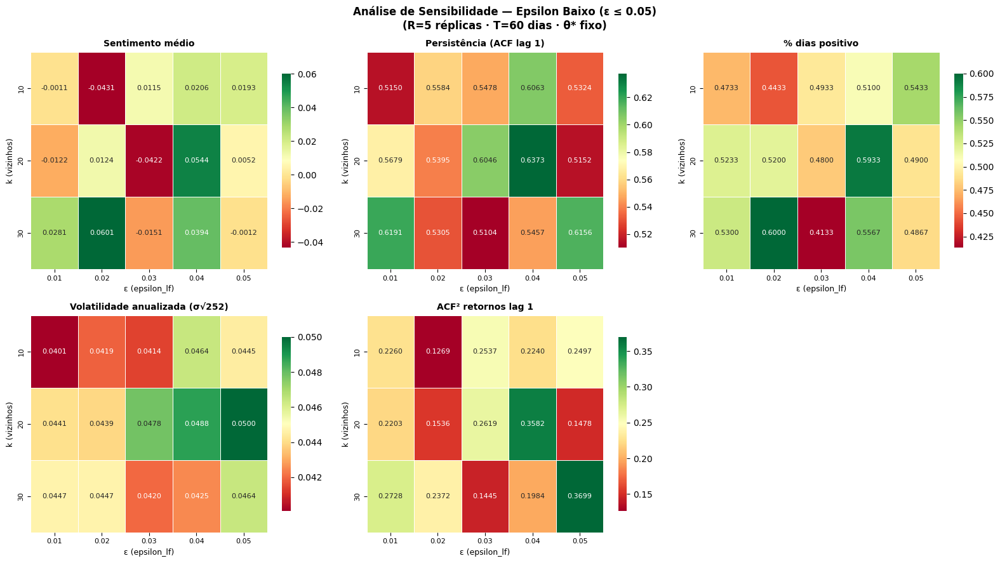

✓ Heatmap salvo: /content/drive/MyDrive/tese_fii/rede_social_epsilon_baixo/figures/heatmap_epsilon_baixo.png


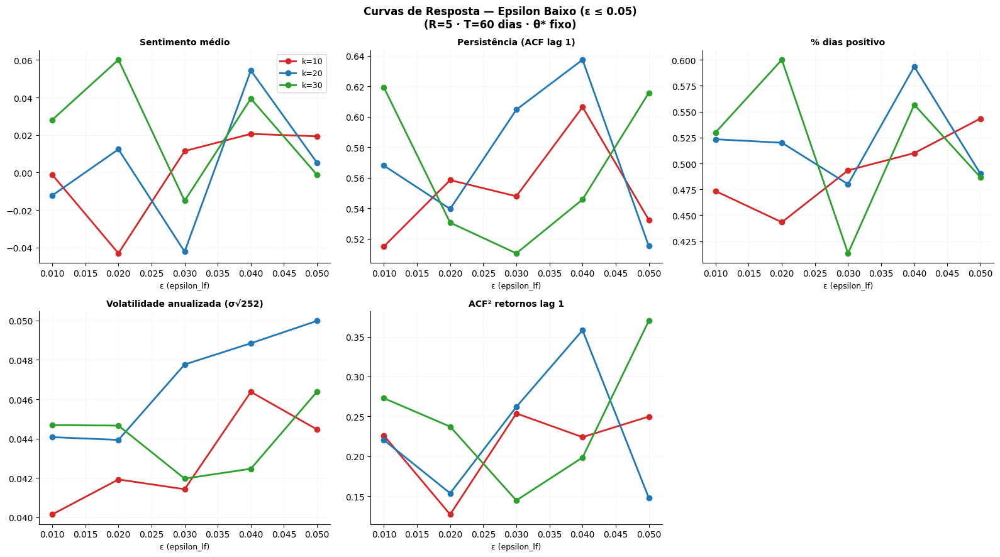

✓ Curvas salvas: /content/drive/MyDrive/tese_fii/rede_social_epsilon_baixo/figures/curvas_epsilon_baixo.png


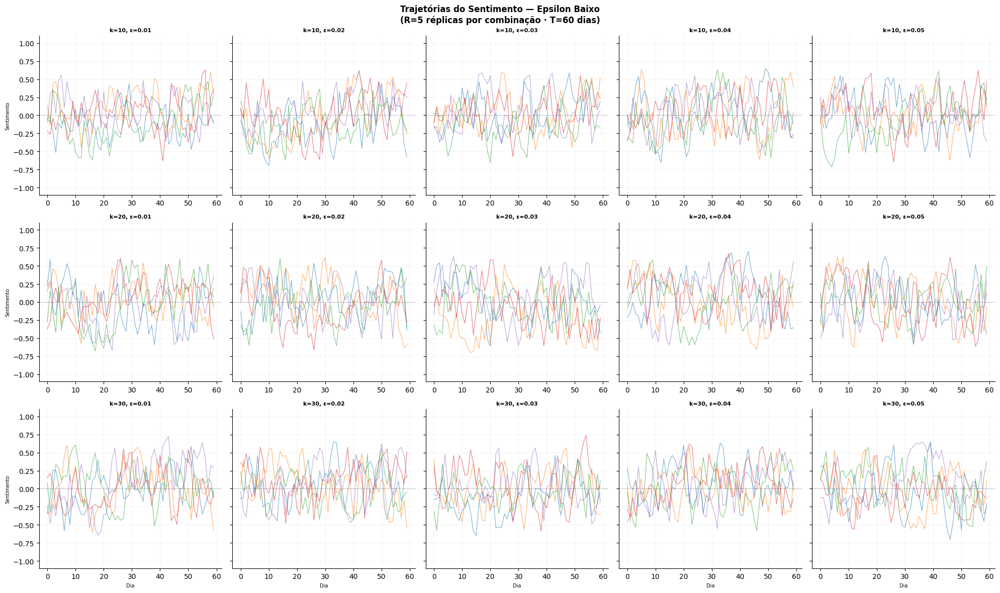

✓ Trajetórias salvas: /content/drive/MyDrive/tese_fii/rede_social_epsilon_baixo/figures/trajetorias_sentimento.png

═══════════════════════════════════════════════════════
  k_ef estimado (epsilon baixo)
───────────────────────────────────────────────────────
epsilon_lf    0.01  0.02  0.03  0.04  0.05
num_vizinhos                              
10             9.9  10.0  10.0  10.0  10.0
20            17.9  20.0  20.0  20.0  20.0
30            21.0  28.8  29.9  30.0  30.0


In [ ]:
# ══════════════════════════════════════════════════════════════
# TABELAS
# ══════════════════════════════════════════════════════════════

METRICAS_TAB = {
    'sent_media':        'Sentimento médio',
    'sent_acf1':         'Persistência (ACF lag 1)',
    'sent_positivo_pct': '% dias positivo',
    'variancia':         'Volatilidade anualizada (σ√252)',
    'acf2_lag1':         'ACF² retornos lag 1',
}

for oname, label in METRICAS_TAB.items():
    df_o = df_res2[df_res2['output'] == oname].copy()
    if oname == 'variancia':
        df_o['mean'] = np.sqrt(df_o['mean'] * 252)
    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean',
        aggfunc='mean'
    ).round(4)
    pivot.index.name   = 'k'
    pivot.columns.name = 'ε'
    print(f"\n{'═'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    print(pivot.to_string())

# ══════════════════════════════════════════════════════════════
# FIGURA 1 — Heatmaps (5 métricas)
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

for j, (oname, label) in enumerate(METRICAS_TAB.items()):
    ax   = axes_flat[j]
    df_o = df_res2[df_res2['output'] == oname].copy()
    if oname == 'variancia':
        df_o['mean'] = np.sqrt(df_o['mean'] * 252)

    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean',
        aggfunc='mean'
    ).round(4)

    sns.heatmap(pivot, ax=ax, cmap='RdYlGn',
                annot=True, fmt='.4f',
                linewidths=0.5,
                cbar_kws={'shrink': 0.8},
                annot_kws={'size': 8})
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('ε (epsilon_lf)', fontsize=9)
    ax.set_ylabel('k (vizinhos)', fontsize=9)
    ax.tick_params(labelsize=8)

axes_flat[5].set_visible(False)

fig.suptitle(
    'Análise de Sensibilidade — Epsilon Baixo (ε ≤ 0.05)\n'
    f'(R={N_REP_2} réplicas · T={HORIZON_2} dias · θ* fixo)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR_2}/heatmap_epsilon_baixo.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Heatmap salvo: {path}')

# ══════════════════════════════════════════════════════════════
# FIGURA 2 — Curvas por k, eixo X = epsilon
# ══════════════════════════════════════════════════════════════

CORES_VIZ2 = ['#d62728', '#1f77b4', '#2ca02c']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

for j, (oname, label) in enumerate(METRICAS_TAB.items()):
    ax   = axes_flat[j]
    df_o = df_res2[df_res2['output'] == oname].copy()
    if oname == 'variancia':
        df_o['mean'] = np.sqrt(df_o['mean'] * 252)

    for n_viz, cor in zip(GRADE_VIZINHOS_2, CORES_VIZ2):
        df_v = df_o[df_o['num_vizinhos'] == n_viz].sort_values('epsilon_lf')
        ax.plot(df_v['epsilon_lf'], df_v['mean'],
                color=cor, lw=2, marker='o', ms=6,
                label=f'k={n_viz}')

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('ε (epsilon_lf)', fontsize=9)
    ax.grid(True, alpha=0.25, ls=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if j == 0:
        ax.legend(fontsize=9)

axes_flat[5].set_visible(False)

fig.suptitle(
    'Curvas de Resposta — Epsilon Baixo (ε ≤ 0.05)\n'
    f'(R={N_REP_2} · T={HORIZON_2} dias · θ* fixo)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR_2}/curvas_epsilon_baixo.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Curvas salvas: {path}')

# ══════════════════════════════════════════════════════════════
# FIGURA 3 — Trajetória do sentimento por combinação
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharey=True)

for i, n_viz in enumerate(GRADE_VIZINHOS_2):
    for j, eps in enumerate(GRADE_EPSILON_2):
        ax = axes[i, j]
        df_s = df_sent2[
            (df_sent2['num_vizinhos'] == n_viz) &
            (df_sent2['epsilon_lf'].round(4) == round(eps, 4))
        ]
        for rep in df_s['replica'].unique():
            serie = df_s[df_s['replica'] == rep]['sentimento'].values
            ax.plot(serie, lw=0.8, alpha=0.6)

        ax.axhline(0, color='black', lw=0.8, ls=':', alpha=0.5)
        ax.set_ylim(-1.1, 1.1)
        ax.set_title(f'k={n_viz}, ε={eps}', fontsize=8, fontweight='bold')
        ax.grid(True, alpha=0.15)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if j == 0:
            ax.set_ylabel('Sentimento', fontsize=7)
        if i == 2:
            ax.set_xlabel('Dia', fontsize=7)

fig.suptitle(
    'Trajetórias do Sentimento — Epsilon Baixo\n'
    f'(R={N_REP_2} réplicas por combinação · T={HORIZON_2} dias)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR_2}/trajetorias_sentimento.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Trajetórias salvas: {path}')

# ══════════════════════════════════════════════════════════════
# k_ef para este experimento
# ══════════════════════════════════════════════════════════════

rows_kef2 = []
for k in GRADE_VIZINHOS_2:
    for eps in GRADE_EPSILON_2:
        k_ef = estimar_k_ef(k, eps)
        rows_kef2.append({
            'num_vizinhos': k,
            'epsilon_lf':   round(eps, 4),
            'k_ef':         round(k_ef, 2),
        })

df_kef2 = pd.DataFrame(rows_kef2)
pivot_kef2 = df_kef2.pivot_table(
    index='num_vizinhos',
    columns='epsilon_lf',
    values='k_ef'
).round(1)

print(f"\n{'═'*55}")
print("  k_ef estimado (epsilon baixo)")
print(f"{'─'*55}")
print(pivot_kef2.to_string())

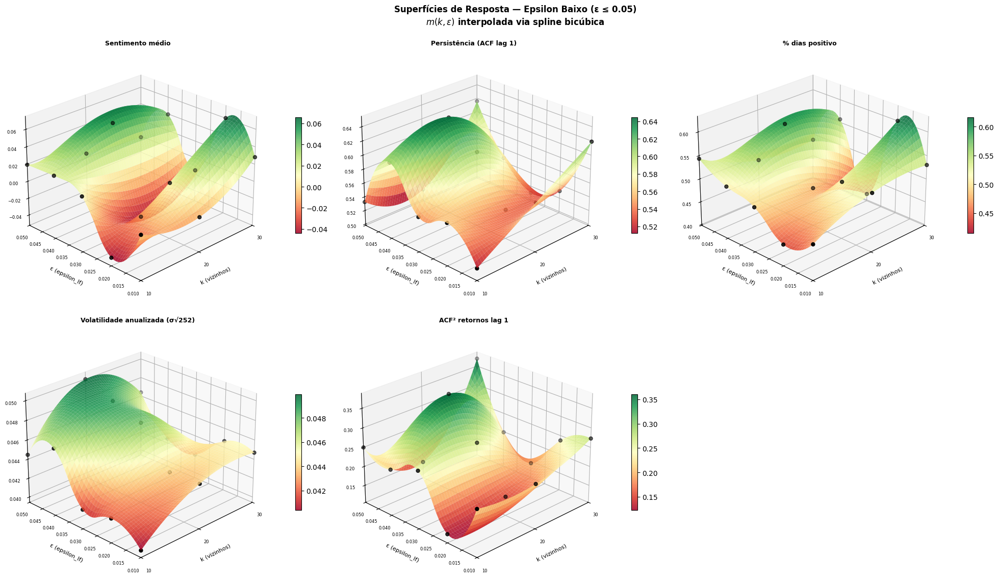

✓ Superfície 3D salva: /content/drive/MyDrive/tese_fii/rede_social_epsilon_baixo/figures/superficie_3d_epsilon_baixo.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# FIGURA 4 — Superfícies 3D (spline bicúbica) — 5 métricas
# ══════════════════════════════════════════════════════════════

from scipy.interpolate import RectBivariateSpline

fig, axes = plt.subplots(2, 3, figsize=(20, 12),
                         subplot_kw={'projection': '3d'})
axes_flat = axes.flatten()

for j, (oname, label) in enumerate(METRICAS_TAB.items()):
    ax   = axes_flat[j]
    df_o = df_res2[df_res2['output'] == oname].copy()
    if oname == 'variancia':
        df_o['mean'] = np.sqrt(df_o['mean'] * 252)

    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean',
        aggfunc='mean'
    )

    k_vals   = pivot.index.values.astype(float)
    eps_vals = pivot.columns.values.astype(float)
    Z        = pivot.values

    spline   = RectBivariateSpline(k_vals, eps_vals, Z, kx=2, ky=2)
    k_fine   = np.linspace(k_vals.min(),   k_vals.max(),   50)
    eps_fine = np.linspace(eps_vals.min(), eps_vals.max(), 50)
    K, E     = np.meshgrid(k_fine, eps_fine)
    Z_fine   = spline(k_fine, eps_fine).T

    surf = ax.plot_surface(K, E, Z_fine, cmap='RdYlGn',
                           alpha=0.85, edgecolor='none')

    K_orig, E_orig = np.meshgrid(k_vals, eps_vals)
    ax.scatter(K_orig.flatten(), E_orig.flatten(), Z.T.flatten(),
               color='black', s=25, zorder=5)

    fig.colorbar(surf, ax=ax, shrink=0.4, pad=0.1)
    ax.set_xlabel('k (vizinhos)', fontsize=8, labelpad=5)
    ax.set_ylabel('ε (epsilon_lf)', fontsize=8, labelpad=5)
    ax.set_xlim(k_vals.min(), k_vals.max())
    ax.set_ylim(eps_vals.min(), eps_vals.max())
    ax.set_xticks(GRADE_VIZINHOS_2)
    ax.set_title(label, fontsize=9, fontweight='bold', pad=8)
    ax.tick_params(labelsize=6)
    ax.view_init(elev=25, azim=225)

axes_flat[5].set_visible(False)

fig.suptitle(
    'Superfícies de Resposta — Epsilon Baixo (ε ≤ 0.05)\n'
    r'$m(k, \varepsilon)$ interpolada via spline bicúbica',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR_2}/superficie_3d_epsilon_baixo.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Superfície 3D salva: {path}')

In [ ]:
# ══════════════════════════════════════════════════════════════
# FIGURA 5 — Superfícies 3D — 16 outputs (spline bicúbica)
# ══════════════════════════════════════════════════════════════

n_cols = 4
n_rows = (len(TODOS_OUTPUTS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 20),
                         subplot_kw={'projection': '3d'})
axes_flat = axes.flatten()

for j, (oname, label) in enumerate(TODOS_OUTPUTS.items()):
    ax   = axes_flat[j]
    df_o = df_res2[df_res2['output'] == oname].copy()

    if oname == 'variancia':
        df_o['mean'] = np.sqrt(df_o['mean'] * 252)

    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean',
        aggfunc='mean'
    )

    k_vals   = pivot.index.values.astype(float)
    eps_vals = pivot.columns.values.astype(float)
    Z        = pivot.values

    spline   = RectBivariateSpline(k_vals, eps_vals, Z, kx=2, ky=2)
    k_fine   = np.linspace(k_vals.min(),   k_vals.max(),   50)
    eps_fine = np.linspace(eps_vals.min(), eps_vals.max(), 50)
    K, E     = np.meshgrid(k_fine, eps_fine)
    Z_fine   = spline(k_fine, eps_fine).T

    surf = ax.plot_surface(K, E, Z_fine, cmap='RdYlGn',
                           alpha=0.85, edgecolor='none')

    K_orig, E_orig = np.meshgrid(k_vals, eps_vals)
    ax.scatter(K_orig.flatten(), E_orig.flatten(), Z.T.flatten(),
               color='black', s=20, zorder=5)

    fig.colorbar(surf, ax=ax, shrink=0.4, pad=0.1)
    ax.set_xlabel('k', fontsize=7, labelpad=5)
    ax.set_ylabel('ε', fontsize=7, labelpad=5)
    ax.set_xlim(k_vals.min(), k_vals.max())
    ax.set_ylim(eps_vals.min(), eps_vals.max())
    ax.set_xticks(GRADE_VIZINHOS_2)
    ax.set_title(label, fontsize=8, fontweight='bold', pad=8)
    ax.tick_params(labelsize=6)
    ax.view_init(elev=25, azim=225)

for j in range(len(TODOS_OUTPUTS), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Superfícies de Resposta — 16 Outputs × Epsilon Baixo (ε ≤ 0.05)\n'
    r'$m(k, \varepsilon)$ interpolada via spline bicúbica',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR_2}/superficie_3d_todos_outputs.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura 16 outputs salva: {path}')

Output hidden; open in https://colab.research.google.com to view.

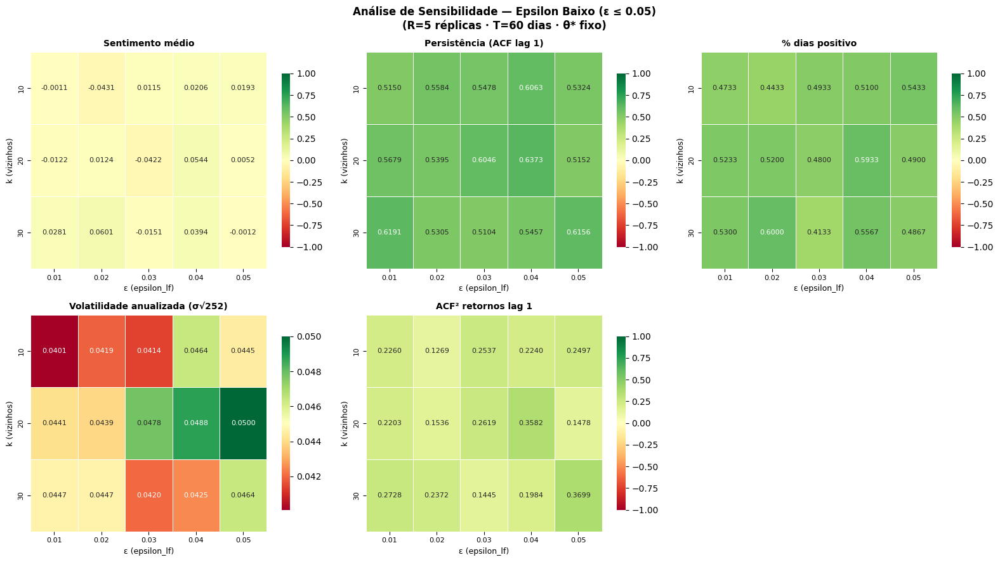

✓ Heatmap salvo: /content/drive/MyDrive/tese_fii/rede_social_epsilon_baixo/figures/heatmap_epsilon_baixo.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))  # sem projection='3d'
axes_flat = axes.flatten()

for j, (oname, label) in enumerate(METRICAS_TAB.items()):
    ax   = axes_flat[j]
    df_o = df_res2[df_res2['output'] == oname].copy()
    if oname == 'variancia':
        df_o['mean'] = np.sqrt(df_o['mean'] * 252)

    pivot = df_o.pivot_table(
        index='num_vizinhos',
        columns='epsilon_lf',
        values='mean',
        aggfunc='mean'
    ).round(4)

    vmin = -1 if oname in ['sent_media', 'sent_acf1', 'sent_positivo_pct', 'acf2_lag1'] else None
    vmax =  1 if oname in ['sent_media', 'sent_acf1', 'sent_positivo_pct', 'acf2_lag1'] else None

    sns.heatmap(pivot, ax=ax, cmap='RdYlGn',
                annot=True, fmt='.4f',
                linewidths=0.5,
                vmin=vmin, vmax=vmax,
                cbar_kws={'shrink': 0.8},
                annot_kws={'size': 8})
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('ε (epsilon_lf)', fontsize=9)
    ax.set_ylabel('k (vizinhos)', fontsize=9)
    ax.tick_params(labelsize=8)

axes_flat[5].set_visible(False)

fig.suptitle(
    'Análise de Sensibilidade — Epsilon Baixo (ε ≤ 0.05)\n'
    f'(R={N_REP_2} réplicas · T={HORIZON_2} dias · θ* fixo)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR_2}/heatmap_epsilon_baixo.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Heatmap salvo: {path}')